# StaticSpinSucep: spin susceptibility from excitonic BSE

This notebook separates the spin-susceptibility problem from the excitonic Bethe-Salpeter notebook. The goal is to build, on a fixed magnetic background, the benchmark electronic bubble and the leading Gaussian excitonic corrections:

$$R^R = R^R_{\rm bare} + R^R_{1D} + R^R_{2D},$$

where $R_{\rm bare}$ is the electronic spin-spin bubble, $R_{1D}$ contains one excitonic propagator $D$ and one two-spin vertex $\partial_M\partial_M\Pi$, and $R_{2D}$ contains two excitonic propagators and two one-spin vertices $\partial_M\Pi$.



## Objects to compute

The retarded spin susceptibility is

$$R^{ab,R}_{ll'}(t)=-i\Theta(t)\langle [s_l^a(t),s_{l'}^b(0)]\rangle,$$

with layer indices $l,l'=1,2$ and spin indices $a,b=x,y,z$. We use

$$s_l^a=\frac{1}{2}c_l^\dagger\sigma^a c_l.$$

For a Hamiltonian without inter-layer tunneling, the electronic benchmark is layer diagonal:

$$R^{ab,R}_{ll',\mathrm{bare}}\propto\delta_{ll'}.$$

The excitonic part starts from the channel-space BSE propagator

$$D^{-1}_{M,\mu\nu}(z,z')=\frac{\delta_{\mu\nu}\delta_C(z,z')}{V}-\Pi_{\mu\nu}(z,z';M),$$

where $\mu,\nu=0,x,y,z$ are excitonic charge/spin-channel indices. The bubble is

$$\Pi_{\mu\nu}(z,z';M)= -\frac{i}{L}\sum_k\mathrm{Tr}_{\sigma}\left[\Gamma_\mu^\dagger G^1_M(k;z,z')\Gamma_\nu G^2_M(k;z',z)\right].$$

For a static magnetic background $M_0$, time-translation invariance lets us use the retarded frequency representation

$$\Pi_{\mu\nu}(z,z';M_0)\rightarrow \Pi^R_{\mu\nu}(\omega;M_0),\qquad D_{M,\mu\nu}(z,z')\rightarrow D^R_{\mu\nu}(\omega;M_0).$$

The single-$D$ excitonic correction contains the two-magnetization vertex

$$\Lambda^{ll',ab,R}_{\mu\nu}(\omega;M_0)\equiv\frac{\partial^2\Pi^R_{\mu\nu}(\omega;M_0)}{\partial M_l^a\partial M_{l'}^b},$$

and is evaluated as

$$R^{ab,R}_{1D,ll'}(\omega;M_0)=C_{1D}\sum_{\mu\nu}D^R_{\mu\nu}(\omega;M_0)\Lambda^{ll',ab,R}_{\nu\mu}(\omega;M_0).$$

The two-$D$ excitonic correction uses the one-magnetization vertex

$$\Lambda^{l,a,R}_{\mu\nu}(\omega;M_0)\equiv\frac{\partial\Pi^R_{\mu\nu}(\omega;M_0)}{\partial M_l^a},$$

and is evaluated in the same static-background approximation as

$$R^{ab,R}_{2D,ll'}(\omega;M_0)=C_{2D}\,\mathrm{Tr}_{\mu}\left[D^R(\omega)\Lambda^{l,a,R}(\omega)D^R(\omega)\Lambda^{l',b,R}(\omega)\right].$$



In [1]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10);


In [2]:
# -----------------------------
# Physical and numerical parameters
# -----------------------------
L = 100
γ = 1.0
Δ_layer = 8.0
Jsd = 0.35
Mmag = 1.0#1.0
θ = pi/4
V = -1.2
T = 0.08#0.2#0.08

# Chemical potentials diagonal in the Hamiltonian.
μchem = 0.0
μbias = 0.0
μ1 = μchem + μbias/2
μ2 = μchem - μbias/2

ηΩ = 0.25#32#16
Ωmin, Ωmax, NΩ = 0.0, 15.0, 401

ks = collect(range(-π, stop=π - 2π/L, length=L))
Ωs = collect(range(Ωmin, Ωmax, length=NΩ));


In [3]:
# Pauli matrices in physical spin space.
σ0 = ComplexF64[1 0; 0 1]
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -1im; 1im 0]
σz = ComplexF64[1 0; 0 -1]

# Physical spin vertices s^a = sigma^a/2.
S_spin = [σx, σy, σz] ./ 2
spin_labels = ["x", "y", "z"]

# Excitonic vertices Gamma^mu = sigma^mu/sqrt(2), mu=0,x,y,z.
Γ_exciton = [σ0, σx, σy, σz] ./ sqrt(2)
channel_labels = ["0", "x", "y", "z"];


In [4]:
ϵk(k; γ=γ) = -2γ*cos(k)

function fermi(E; T=T, μ=0.0)
    x = (E - μ) / T
    x > 60 && return 0.0
    x < -60 && return 1.0
    return 1 / (exp(x) + 1)
end

layer_chemical_potential(layer::Int) = layer == 1 ? μ1 : μ2

function h_layer(k, M; layer::Int)
    offset = layer == 1 ? +Δ_layer/2 : Δ_layer/2
    energy = (ϵk(k) + offset) * σ0 - Jsd * (M[1]*σx + M[2]*σy + M[3]*σz)
    energy .*= (-1)^(layer+1)
    energy .-= layer_chemical_potential(layer) * σ0
    return energy
end

function magnetizations(θ)
    M1 = Mmag .* [0.0, 0.0, 1.0]
    M2 = Mmag .* [sin(θ), 0.0, cos(θ)]
    return M1, M2
end

function diagonalize_layers(ks, θ)
    M1, M2 = magnetizations(θ)
    E1 = zeros(Float64, 2, length(ks))
    E2 = zeros(Float64, 2, length(ks))
    U1 = Vector{Matrix{ComplexF64}}(undef, length(ks))
    U2 = Vector{Matrix{ComplexF64}}(undef, length(ks))

    for (ik, k) in enumerate(ks)
        F1 = eigen(Hermitian(h_layer(k, M1; layer=1)))
        F2 = eigen(Hermitian(h_layer(k, M2; layer=2)))
        E1[:, ik] .= F1.values
        E2[:, ik] .= F2.values
        U1[ik] = Matrix{ComplexF64}(F1.vectors)
        U2[ik] = Matrix{ComplexF64}(F2.vectors)
    end

    return (; M1, M2, E1, E2, U1, U2)
end;


## $R_{\rm bare}$: electronic spin-spin bubble

In equilibrium we use the retarded band expression

$$R^{ab,R}_{l,{\rm bare}}(\Omega)=\frac{1}{L}\sum_{k,n,m}\frac{f(E_{lnk})-f(E_{lmk})}{\Omega+i\eta-(E_{lmk}-E_{lnk})}\,S^a_{nm}(k)S^b_{mn}(k).$$

Because there is no inter-layer tunneling, this contribution is diagonal in layer: $R_{12,{\rm bare}}=R_{21,{\rm bare}}=0$.


In [5]:
function spin_susceptibility_bare_band(Ωs, ks, θ; η=ηΩ)
    data = diagonalize_layers(ks, θ)
    R = zeros(ComplexF64, 2, 2, 3, 3, length(Ωs))

    for layer in 1:2
        E = layer == 1 ? data.E1 : data.E2
        U = layer == 1 ? data.U1 : data.U2

        for (ik, _) in enumerate(ks)
            Uk = U[ik]
            Sa = [Uk' * S_spin[a] * Uk for a in 1:3]

            for n in 1:2, m in 1:2
                ΔE = E[m, ik] - E[n, ik]
                occ = fermi(E[n, ik]) - fermi(E[m, ik])

                for (iΩ, Ω) in enumerate(Ωs)
                    pref = occ / (Ω + 1im*η - ΔE) / length(ks)
                    for a in 1:3, b in 1:3
                        R[layer, layer, a, b, iΩ] += pref * Sa[a][n, m] * Sa[b][m, n]
                    end
                end
            end
        end
    end

    return R, data
end;


## $R_{1D}$: excitonic term with a single $D$

The next contribution comes from

$$i\mathrm{Tr}\ln D_M^{-1},\qquad D_M^{-1}=V^{-1}-\Pi[M].$$

Taking two derivatives with respect to the classical moments gives a term with one excitonic propagator and one two-magnetization vertex:

$$R^{ab,R}_{1D,ll'}(\omega;M_0)=C_{1D}\sum_{\mu\nu}D^R_{\mu\nu}(\omega;M_0)\Lambda^{ll',ab,R}_{\nu\mu}(\omega;M_0),$$

with

$$\Lambda^{ll',ab,R}_{\mu\nu}(\omega;M_0)=\partial_{M_l^a}\partial_{M_{l'}^b}\Pi^R_{\mu\nu}(\omega;M_0).$$

This is the static-background version of the two-vertex object in the document. The word "two-vertex" here refers to the two spin/magnetization insertions inside $\Lambda_{ab}$, not to the later term with two separate excitonic propagators.

For example, the contour object corresponding to one cross-layer component has the indexed structure

$$\Lambda^{21}_{ab,\mu\nu}(z,z';\bar z,\bar z')\propto -\frac{iJ_{sd}^2}{L}\sum_k\mathrm{Tr}_{\sigma}\left[\Gamma_\mu G^2_M(z,\bar z)\sigma_aG^2_M(\bar z,z')\Gamma_\nu G^1_M(z',\bar z')\sigma_bG^1_M(\bar z',z)\right],$$

up to the precise contour ordering and sign convention. The important point for the notebook is that $\Lambda^{ll',ab}_{\mu\nu}$ remains a $4\times4$ matrix in excitonic channel space before being contracted with $D_{\mu\nu}$.


In [6]:
function diagonalize_layers_from_M(ks, M1, M2)
    E1 = zeros(Float64, 2, length(ks))
    E2 = zeros(Float64, 2, length(ks))
    U1 = Vector{Matrix{ComplexF64}}(undef, length(ks))
    U2 = Vector{Matrix{ComplexF64}}(undef, length(ks))

    for (ik, k) in enumerate(ks)
        F1 = eigen(Hermitian(h_layer(k, M1; layer=1)))
        F2 = eigen(Hermitian(h_layer(k, M2; layer=2)))
        E1[:, ik] .= F1.values
        E2[:, ik] .= F2.values
        U1[ik] = Matrix{ComplexF64}(F1.vectors)
        U2[ik] = Matrix{ComplexF64}(F2.vectors)
    end

    return (; M1, M2, E1, E2, U1, U2)
end

function polarization_R_band_from_M(Ωs, ks, M1, M2; η=ηΩ)
    data = diagonalize_layers_from_M(ks, M1, M2)
    Π = zeros(ComplexF64, 4, 4, length(Ωs))

    for (ik, _) in enumerate(ks)
        U1k = data.U1[ik]
        U2k = data.U2[ik]
        Mμ = [U1k' * Γ_exciton[μ] * U2k for μ in 1:4]

        for a in 1:2, b in 1:2
            ΔE = data.E1[a, ik] - data.E2[b, ik]
            occ = fermi(data.E2[b, ik]) - fermi(data.E1[a, ik])

            for (iΩ, Ω) in enumerate(Ωs)
                pref = occ / (Ω + 1im*η - ΔE) / length(ks)
                for μ in 1:4, ν in 1:4
                    Π[μ, ν, iΩ] += pref * Mμ[μ][a, b] * conj(Mμ[ν][a, b])
                end
            end
        end
    end

    return Π, data
end

function exciton_propagator(Π; V=V)
    D = similar(Π)
    VinvI = (1/V) * Matrix{ComplexF64}(I, 4, 4)
    for iΩ in axes(Π, 3)
        D[:, :, iΩ] .= inv(VinvI - Π[:, :, iΩ])
    end
    return D
end;


## Explicit retarded two-magnetization vertex

The object needed for the single-$D$ correction is the analytic two-spin vertex

$$\Lambda^{ll',ab,R}_{\mu\nu}(\Omega;M_0)=\partial_{M_l^a}\partial_{M_{l'}^b}\Pi^R_{\mu\nu}(\Omega;M_0).$$

In practice we do not evaluate this by finite differences. The derivatives generate explicit spin insertions on the electronic Green functions. For the static background, the retarded bubble is obtained from the contour bubble by the Langreth rule

$$\Pi^R_{\mu\nu}(\Omega)=-\frac{i}{L}\sum_k\int\frac{d\omega}{2\pi}\mathrm{Tr}_\sigma\left[\Gamma_\mu^\dagger G^{1,R}(\omega+\Omega)\Gamma_\nu G^{2,<}(\omega)+\Gamma_\mu^\dagger G^{1,<}(\omega+\Omega)\Gamma_\nu G^{2,A}(\omega)\right].$$

The same Langreth structure applies after the spin insertions are included. For example, a first insertion on layer $l$ is

$$\partial_{M_l^a}G_l^R=G_l^R h_l^a G_l^R,\qquad h_l^a\equiv\partial_{M_l^a}H_l=(-1)^{l+1}(-J_{sd})\sigma^a,$$

and in equilibrium

$$\partial_{M_l^a}G_l^< = f(\omega)\left(\partial_{M_l^a}G_l^A-\partial_{M_l^a}G_l^R\right),$$

which is equivalent to applying the full Langreth rule to $G h_l^a G$. For two insertions on the same layer, because $H_l$ is linear in $M_l$,

$$\partial_{M_l^a}\partial_{M_l^b}G_l^X = G_l^X h_l^bG_l^X h_l^aG_l^X+G_l^X h_l^aG_l^X h_l^bG_l^X,$$

with $X=R,A,<$. Thus `:langreth` evaluates the analytic vertex with the explicit internal-frequency integral.


In [7]:
# Independent internal-frequency grid for the explicit Langreth vertex.
ωv_min, ωv_max, Nωv = -15.0, 15.0, 401
ωs_vertex = collect(range(ωv_min, ωv_max, length=Nωv))
dω_vertex = ωs_vertex[2] - ωs_vertex[1]

# Electronic broadening used inside the explicit Green functions.
ηe = ηΩ / 2;


In [8]:
function green_R(h, ω; η=ηe)
    return inv((ω + 1im*η) * σ0 - h)
end

green_A(h, ω; η=ηe) = green_R(h, ω; η=η)'

green_less(h, ω; η=ηe) = fermi(ω) * (green_A(h, ω; η=η) - green_R(h, ω; η=η))

function dh_dM(layer::Int, comp::Int)
    # This derivative follows the current h_layer convention, including the layer-dependent sign.
    layer_sign = (-1)^(layer + 1)
    return layer_sign * (-Jsd) * (2 * S_spin[comp])
end

function green_derivative(h, ω, dh; η=ηe)
    GR = green_R(h, ω; η=η)
    GA = GR'
    dGR = GR * dh * GR
    dGA = dGR'
    dGL = fermi(ω) * (dGA - dGR)
    return (; R=dGR, A=dGA, L=dGL)
end

function green_second_derivative(h, ω, dha, dhb; η=ηe)
    GR = green_R(h, ω; η=η)
    GA = GR'
    d2GR = GR * dhb * GR * dha * GR + GR * dha * GR * dhb * GR
    d2GA = d2GR'
    d2GL = fermi(ω) * (d2GA - d2GR)
    return (; R=d2GR, A=d2GA, L=d2GL)
end;


## Langreth evaluation of $\Lambda^{ll',ab,R}_{\mu\nu}$

The code below evaluates the analytic vertex using the retarded Langreth expression. This means that the internal frequency $\omega$ is kept explicitly and integrated numerically.

For $l=l'=1$, both spin insertions sit on the layer-1 line:

$$\Gamma_\mu^\dagger (\partial_a\partial_b G^{1,R})\Gamma_\nu G^{2,<}+\Gamma_\mu^\dagger (\partial_a\partial_b G^{1,<})\Gamma_\nu G^{2,A}.$$

For a cross-layer component, e.g. $l=2,l'=1$, one first derivative sits on each line:

$$\Gamma_\mu^\dagger (\partial_b G^{1,R})\Gamma_\nu(\partial_a G^{2,<})+\Gamma_\mu^\dagger (\partial_b G^{1,<})\Gamma_\nu(\partial_a G^{2,A}).$$

The full routine keeps all indices,

$$\Lambda[l,l',a,b,\mu,\nu,i\Omega],$$

while the faster reduced routine keeps only diagonal spin components $a=b$ for one selected layer pair.


In [9]:
function lambda_two_vertex_explicit_langreth(Ωs, ωs, ks, θ; η=ηe)
    M1, M2 = magnetizations(θ)
    Λ = zeros(ComplexF64, 2, 2, 3, 3, 4, 4, length(Ωs))
    dω_local = length(ωs) > 1 ? ωs[2] - ωs[1] : 1.0

    for k in ks
        h1 = h_layer(k, M1; layer=1)
        h2 = h_layer(k, M2; layer=2)
        dh = [[dh_dM(layer, comp) for comp in 1:3] for layer in 1:2]

        for (iΩ, Ω) in enumerate(Ωs)
            acc = zeros(ComplexF64, 2, 2, 3, 3, 4, 4)

            for ω in ωs
                G1R = green_R(h1, ω + Ω; η=η)
                G1A = G1R'
                G1L = fermi(ω + Ω) * (G1A - G1R)
                G2R = green_R(h2, ω; η=η)
                G2A = G2R'
                G2L = fermi(ω) * (G2A - G2R)

                dG1 = [green_derivative(h1, ω + Ω, dh[1][a]; η=η) for a in 1:3]
                dG2 = [green_derivative(h2, ω, dh[2][a]; η=η) for a in 1:3]
                d2G1 = [[green_second_derivative(h1, ω + Ω, dh[1][a], dh[1][b]; η=η) for b in 1:3] for a in 1:3]
                d2G2 = [[green_second_derivative(h2, ω, dh[2][a], dh[2][b]; η=η) for b in 1:3] for a in 1:3]

                for μ in 1:4, ν in 1:4
                    Γμ = Γ_exciton[μ]
                    Γν = Γ_exciton[ν]
                    Γμd = Γμ'

                    for a in 1:3, b in 1:3
                        # l=1, l'=1: both insertions on the layer-1 line.
                        acc[1, 1, a, b, μ, ν] += tr(Γμd * d2G1[a][b].R * Γν * G2L +
                                                     Γμd * d2G1[a][b].L * Γν * G2A)

                        # l=2, l'=2: both insertions on the layer-2 line.
                        acc[2, 2, a, b, μ, ν] += tr(Γμd * G1R * Γν * d2G2[a][b].L +
                                                     Γμd * G1L * Γν * d2G2[a][b].A)

                        # l=1, l'=2: first insertion on layer 1, second on layer 2.
                        acc[1, 2, a, b, μ, ν] += tr(Γμd * dG1[a].R * Γν * dG2[b].L +
                                                     Γμd * dG1[a].L * Γν * dG2[b].A)

                        # l=2, l'=1: first insertion on layer 2, second on layer 1.
                        acc[2, 1, a, b, μ, ν] += tr(Γμd * dG1[b].R * Γν * dG2[a].L +
                                                     Γμd * dG1[b].L * Γν * dG2[a].A)
                    end
                end
            end

            Λ[:, :, :, :, :, :, iΩ] .+= (-1im) .* acc .* dω_local ./ (2π * length(ks))
        end
    end

    return Λ
end

function spin_susceptibility_oneD_explicit_langreth(Ωs, ωs, ks, θ; η=ηe, prefactor=-1im)
    M1, M2 = magnetizations(θ)
    Π0, data0 = polarization_R_band_from_M(Ωs, ks, M1, M2; η=ηΩ)
    D = exciton_propagator(Π0; V=V)
    Λ = lambda_two_vertex_explicit_langreth(Ωs, ωs, ks, θ; η=η)
    R1D = zeros(ComplexF64, 2, 2, 3, 3, length(Ωs))

    for l in 1:2, lp in 1:2, a in 1:3, b in 1:3, iΩ in axes(Ωs, 1)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λ[l, lp, a, b, ν, μ, iΩ]
        end
        R1D[l, lp, a, b, iΩ] = prefactor * acc
    end

    return R1D, Λ, D, Π0, data0
end
function precompute_exciton_D(Ωs, ks, θ; V=V, η=ηΩ)
    M1, M2 = magnetizations(θ)
    Π, data = polarization_R_band_from_M(Ωs, ks, M1, M2; η=η)
    D = exciton_propagator(Π; V=V)
    return D, Π, data
end

function lambda_layerpair_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    M1, M2 = magnetizations(θ)
    Λdiag = zeros(ComplexF64, 3, 4, 4, length(Ωs))
    dω_local = length(ωs) > 1 ? ωs[2] - ωs[1] : 1.0
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for k in ks
        h1 = h_layer(k, M1; layer=1)
        h2 = h_layer(k, M2; layer=2)

        for (iΩ, Ω) in enumerate(Ωs)
            acc = zeros(ComplexF64, 3, 4, 4)

            for ω in ωs
                G1R = green_R(h1, ω + Ω; η=η)
                G1A = G1R'
                G1L = fermi(ω + Ω) * (G1A - G1R)

                G2R = green_R(h2, ω; η=η)
                G2A = G2R'
                G2L = fermi(ω) * (G2A - G2R)

                for a in 1:3
                    if l == 1 && lp == 1
                        d2G1R = 2 * G1R * dh1[a] * G1R * dh1[a] * G1R
                        d2G1A = d2G1R'
                        d2G1L = fermi(ω + Ω) * (d2G1A - d2G1R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * d2G1R * Γν * G2L +
                                                Γμd * d2G1L * Γν * G2A)
                        end
                    elseif l == 2 && lp == 2
                        d2G2R = 2 * G2R * dh2[a] * G2R * dh2[a] * G2R
                        d2G2A = d2G2R'
                        d2G2L = fermi(ω) * (d2G2A - d2G2R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * G1R * Γν * d2G2L +
                                                Γμd * G1L * Γν * d2G2A)
                        end
                    else
                        dG1R = G1R * dh1[a] * G1R
                        dG1A = dG1R'
                        dG1L = fermi(ω + Ω) * (dG1A - dG1R)

                        dG2R = G2R * dh2[a] * G2R
                        dG2A = dG2R'
                        dG2L = fermi(ω) * (dG2A - dG2R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * dG1R * Γν * dG2L +
                                                Γμd * dG1L * Γν * dG2A)
                        end
                    end
                end
            end

            Λdiag[:, :, :, iΩ] .+= (-1im) .* acc .* dω_local ./ (2π * length(ks))
        end
    end

    return Λdiag
end

function contract_singleD_diag(D, Λdiag; prefactor=-1im)
    Rdiag = zeros(ComplexF64, 3, size(D, 3))

    for a in 1:3, iΩ in axes(D, 3)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λdiag[a, ν, μ, iΩ]
        end
        Rdiag[a, iΩ] = prefactor * acc
    end

    return Rdiag
end

function spin_susceptibility_oneD_diag_explicit_langreth(D, Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe, prefactor=-1im)
    Λdiag = lambda_layerpair_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=layer_pair, η=η)
    Rdiag = contract_singleD_diag(D, Λdiag; prefactor=prefactor)
    return Rdiag, Λdiag
end

function spin_susceptibility_oneD_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe, prefactor=-1im, V=V)
    D, Π, data = precompute_exciton_D(Ωs, ks, θ; V=V, η=ηΩ)
    Rdiag, Λdiag = spin_susceptibility_oneD_diag_explicit_langreth(D, Ωs, ωs, ks, θ; layer_pair=layer_pair, η=η, prefactor=prefactor)
    return Rdiag, Λdiag, D, Π, data
end;


## Fast Lehmann evaluation of the analytic vertex

The `:band` method evaluates the same analytic vertex in the eigenstate basis of $H_1(k)$ and $H_2(k)$. It is not a finite-difference derivative and it does not introduce a new approximation beyond the same equilibrium, static-background assumptions.

Starting from the vertex with explicit spin insertions, we insert resolutions of identity in each layer,

$$1_l=\sum_n |l,n,k\rangle\langle l,n,k|,$$

and transform the already-derived spin-insertion matrices and exciton vertices to the band basis. In the present Hamiltonian the derivative has already been taken, so

$$h_l^a\equiv\partial_{M_l^a}H_l=(-1)^{l+1}(-J_{sd})\sigma^a,$$

using the same layer-sign convention as `h_layer`. Thus

$$h^a_{1,pr}=\langle 1,p|h_1^a|1,r\rangle,\qquad h^a_{2,qs}=\langle 2,q|h_2^a|2,s\rangle,$$

$$\Gamma^\mu_{rq}=\langle 1,r|\Gamma_\mu|2,q\rangle.$$

The frequency integral over products of Green functions is then analytic. The result can be written compactly with divided differences of

$$K_\Omega(x,y)=\frac{f(y)-f(x)}{\Omega+i\eta-(x-y)},$$

where $x$ is a layer-1 eigenvalue and $y$ is a layer-2 eigenvalue. Two insertions on layer 1 use $K_\Omega^{[2,0]}$, two insertions on layer 2 use $K_\Omega^{[0,2]}$, and cross-layer insertions use $K_\Omega^{[1,1]}$. For example,

$$\Lambda^{12,aa,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,r,q,s}K_\Omega^{[1,1]}(E_{1p},E_{1r};E_{2q},E_{2s})h^a_{1,pr}\Gamma^\mu_{rq}h^a_{2,qs}(\Gamma^\nu_{ps})^*.$$

This is why `:band` no longer uses the auxiliary grid `ωsχ`; it is the eigenstate-basis evaluation of the same Langreth vertex after the equilibrium frequency integral has been done analytically.


In [10]:
function fermi_prime(E; T=T, μ=0.0)
    f = fermi(E; T=T, μ=μ)
    return -(f * (1 - f)) / T
end

function fermi_second(E; T=T, μ=0.0)
    f = fermi(E; T=T, μ=μ)
    return f * (1 - f) * (1 - 2f) / T^2
end

function kernel_K(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    return (fermi(y) - fermi(x)) / q
end

function kernel_Kx(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return -fermi_prime(x) / q + n / q^2
end

function kernel_Ky(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return fermi_prime(y) / q - n / q^2
end

function kernel_Kxx(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return -fermi_second(x) / q - 2 * fermi_prime(x) / q^2 + 2 * n / q^3
end

function kernel_Kyy(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return fermi_second(y) / q - 2 * fermi_prime(y) / q^2 + 2 * n / q^3
end

function kernel_Kxy(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return (fermi_prime(x) + fermi_prime(y)) / q^2 - 2 * n / q^3
end

same_node(a, b) = abs(a - b) < 1e-10

function dd1_x(Ω, x1, x2, y, η=ηΩ)
    same_node(x1, x2) && return kernel_Kx(Ω, x1, y, η)
    return (kernel_K(Ω, x1, y, η) - kernel_K(Ω, x2, y, η)) / (x1 - x2)
end

function dd1_y(Ω, x, y1, y2, η=ηΩ)
    same_node(y1, y2) && return kernel_Ky(Ω, x, y1, η)
    return (kernel_K(Ω, x, y1, η) - kernel_K(Ω, x, y2, η)) / (y1 - y2)
end

function dd2_x(Ω, x1, x2, x3, y, η=ηΩ)
    if same_node(x1, x2) && same_node(x2, x3)
        return kernel_Kxx(Ω, x1, y, η) / 2
    elseif same_node(x1, x2)
        return (kernel_Kx(Ω, x1, y, η) - dd1_x(Ω, x1, x3, y, η)) / (x1 - x3)
    elseif same_node(x2, x3)
        return (dd1_x(Ω, x1, x2, y, η) - kernel_Kx(Ω, x2, y, η)) / (x1 - x2)
    elseif same_node(x1, x3)
        return (kernel_Kx(Ω, x1, y, η) - dd1_x(Ω, x1, x2, y, η)) / (x1 - x2)
    else
        return (dd1_x(Ω, x1, x2, y, η) - dd1_x(Ω, x2, x3, y, η)) / (x1 - x3)
    end
end

function dd2_y(Ω, x, y1, y2, y3, η=ηΩ)
    if same_node(y1, y2) && same_node(y2, y3)
        return kernel_Kyy(Ω, x, y1, η) / 2
    elseif same_node(y1, y2)
        return (kernel_Ky(Ω, x, y1, η) - dd1_y(Ω, x, y1, y3, η)) / (y1 - y3)
    elseif same_node(y2, y3)
        return (dd1_y(Ω, x, y1, y2, η) - kernel_Ky(Ω, x, y2, η)) / (y1 - y2)
    elseif same_node(y1, y3)
        return (kernel_Ky(Ω, x, y1, η) - dd1_y(Ω, x, y1, y2, η)) / (y1 - y2)
    else
        return (dd1_y(Ω, x, y1, y2, η) - dd1_y(Ω, x, y2, y3, η)) / (y1 - y3)
    end
end

function dd_xy(Ω, x1, x2, y1, y2, η=ηΩ)
    if same_node(x1, x2) && same_node(y1, y2)
        return kernel_Kxy(Ω, x1, y1, η)
    elseif same_node(x1, x2)
        return (kernel_Kx(Ω, x1, y1, η) - kernel_Kx(Ω, x1, y2, η)) / (y1 - y2)
    elseif same_node(y1, y2)
        return (kernel_Ky(Ω, x1, y1, η) - kernel_Ky(Ω, x2, y1, η)) / (x1 - x2)
    else
        return (kernel_K(Ω, x1, y1, η) - kernel_K(Ω, x2, y1, η) -
                kernel_K(Ω, x1, y2, η) + kernel_K(Ω, x2, y2, η)) / ((x1 - x2) * (y1 - y2))
    end
end

function projectors_from_eigenvectors(U)
    return [U[:, n] * U[:, n]' for n in 1:2]
end

function lambda_layerpair_diag_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    data = diagonalize_layers(ks, θ)
    Λdiag = zeros(ComplexF64, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, μ in 1:4, ν in 1:4
                acc = zero(ComplexF64)
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h2a = dh2e[a]

                if l == 1 && lp == 1
                    for p in 1:2, r in 1:2, s in 1:2, q in 1:2
                        coeff = 2 * dd2_x(Ω, E1[p], E1[r], E1[s], E2[q], η)
                        acc += coeff * h1a[p, r] * h1a[r, s] * Γμ[s, q] * conj(Γν[p, q])
                    end
                elseif l == 2 && lp == 2
                    for p in 1:2, q in 1:2, r in 1:2, s in 1:2
                        coeff = 2 * dd2_y(Ω, E1[p], E2[q], E2[r], E2[s], η)
                        acc += coeff * Γμ[p, q] * h2a[q, r] * h2a[r, s] * conj(Γν[p, s])
                    end
                else
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1a[p, r] * Γμ[r, q] * h2a[q, s] * conj(Γν[p, s])
                    end
                end

                Λdiag[a, μ, ν, iΩ] += acc / length(ks)
            end
        end
    end

    return Λdiag, data
end

function spin_susceptibility_oneD_diag_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im)
    Λdiag, data = lambda_layerpair_diag_band(Ωs, ks, θ; layer_pair=layer_pair, η=η)
    Rdiag = contract_singleD_diag(D, Λdiag; prefactor=prefactor)
    return Rdiag, Λdiag, data
end

function spin_susceptibility_oneD_diag_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im, V=V)
    D, Π, dataD = precompute_exciton_D(Ωs, ks, θ; V=V, η=η)
    Rdiag, Λdiag, dataΛ = spin_susceptibility_oneD_diag_band(D, Ωs, ks, θ; layer_pair=layer_pair, η=η, prefactor=prefactor)
    return Rdiag, Λdiag, D, Π, dataD, dataΛ
end;

function lambda_layerpair_full_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    data = diagonalize_layers(ks, θ)
    Λ = zeros(ComplexF64, 3, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, b in 1:3, μ in 1:4, ν in 1:4
                acc = zero(ComplexF64)
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h1b = dh1e[b]
                h2a = dh2e[a]
                h2b = dh2e[b]

                if l == 1 && lp == 1
                    for p in 1:2, r in 1:2, s in 1:2, q in 1:2
                        coeff = dd2_x(Ω, E1[p], E1[r], E1[s], E2[q], η)
                        acc += coeff * (h1b[p, r] * h1a[r, s] + h1a[p, r] * h1b[r, s]) * Γμ[s, q] * conj(Γν[p, q])
                    end
                elseif l == 2 && lp == 2
                    for p in 1:2, q in 1:2, r in 1:2, s in 1:2
                        coeff = dd2_y(Ω, E1[p], E2[q], E2[r], E2[s], η)
                        acc += coeff * Γμ[p, q] * (h2a[q, r] * h2b[r, s] + h2b[q, r] * h2a[r, s]) * conj(Γν[p, s])
                    end
                elseif l == 1 && lp == 2
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1a[p, r] * Γμ[r, q] * h2b[q, s] * conj(Γν[p, s])
                    end
                else
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1b[p, r] * Γμ[r, q] * h2a[q, s] * conj(Γν[p, s])
                    end
                end

                Λ[a, b, μ, ν, iΩ] += acc / length(ks)
            end
        end
    end

    return Λ, data
end

function contract_singleD_full(D, Λ; prefactor=-1im)
    R = zeros(ComplexF64, 3, 3, size(D, 3))

    for a in 1:3, b in 1:3, iΩ in axes(D, 3)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λ[a, b, ν, μ, iΩ]
        end
        R[a, b, iΩ] = prefactor * acc
    end

    return R
end

function spin_susceptibility_oneD_full_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im)
    Λ, data = lambda_layerpair_full_band(Ωs, ks, θ; layer_pair=layer_pair, η=η)
    R = contract_singleD_full(D, Λ; prefactor=prefactor)
    return R, Λ, data
end;


## $R_{2D}$: excitonic term with two $D$ propagators

The second excitonic contribution from the same Gaussian action is

$$R^{ab,R}_{2D,ll'}(\Omega;M_0)=C_{2D}\,\mathrm{Tr}_{\mu}\left[D^R(\Omega)\Lambda^{l,a,R}(\Omega)D^R(\Omega)\Lambda^{l',b,R}(\Omega)\right],$$

where

$$\Lambda^{l,a,R}_{\mu\nu}(\Omega;M_0)=\partial_{M_l^a}\Pi^R_{\mu\nu}(\Omega;M_0).$$

The prefactor is set to `1im`, matching the sign convention in the document,

$$R^{(II)}_\Phi=i\,\mathrm{Tr}\left[D_0\Lambda_l^aD_0\Lambda_{l'}^b\right].$$

This is the same static-background, frequency-by-frequency approximation used above for $R_{1D}$: we first evaluate the equilibrium $\Pi^R(\Omega;M_0)$ and its magnetization derivatives, then contract the channel matrices at the same external frequency. The fully dynamic Keldysh expression would instead contain a bosonic frequency convolution and the corresponding retarded/Keldysh components of the two $D$ lines.

In the band basis the one-spin vertices are

$$\Lambda^{1,a,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,r,q}K_\Omega^{[1,0]}(E_{1p},E_{1r};E_{2q})h^a_{1,pr}\Gamma^\mu_{rq}(\Gamma^\nu_{pq})^*,$$

$$\Lambda^{2,a,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,q,r}K_\Omega^{[0,1]}(E_{1p};E_{2q},E_{2r})\Gamma^\mu_{pq}h^a_{2,qr}(\Gamma^\nu_{pr})^*.$$



In [11]:
function lambda_one_spin_layers_band(Ωs, ks, θ; η=ηΩ)
    data = diagonalize_layers(ks, θ)
    Λone = zeros(ComplexF64, 2, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, μ in 1:4, ν in 1:4
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h2a = dh2e[a]

                acc1 = zero(ComplexF64)
                for p in 1:2, r in 1:2, q in 1:2
                    coeff = dd1_x(Ω, E1[p], E1[r], E2[q], η)
                    acc1 += coeff * h1a[p, r] * Γμ[r, q] * conj(Γν[p, q])
                end

                acc2 = zero(ComplexF64)
                for p in 1:2, q in 1:2, r in 1:2
                    coeff = dd1_y(Ω, E1[p], E2[q], E2[r], η)
                    acc2 += coeff * Γμ[p, q] * h2a[q, r] * conj(Γν[p, r])
                end

                Λone[1, a, μ, ν, iΩ] += acc1 / length(ks)
                Λone[2, a, μ, ν, iΩ] += acc2 / length(ks)
            end
        end
    end

    return Λone, data
end

function contract_twoD(D, Λone; prefactor=1im)
    R2D = zeros(ComplexF64, 2, 2, 3, 3, size(D, 3))

    @views for iΩ in axes(D, 3), l in 1:2, lp in 1:2, a in 1:3, b in 1:3
        R2D[l, lp, a, b, iΩ] = prefactor * tr(D[:, :, iΩ] * Λone[l, a, :, :, iΩ] * D[:, :, iΩ] * Λone[lp, b, :, :, iΩ])
    end

    return R2D
end

function spin_susceptibility_twoD_band(D, Ωs, ks, θ; η=ηΩ, prefactor=1im)
    Λone, data = lambda_one_spin_layers_band(Ωs, ks, θ; η=η)
    R2D = contract_twoD(D, Λone; prefactor=prefactor)
    return R2D, Λone, data
end

function spin_susceptibility_twoD_diag_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=1im)
    R2D, Λone, data = spin_susceptibility_twoD_band(D, Ωs, ks, θ; η=η, prefactor=prefactor)
    l, lp = layer_pair
    Rdiag = zeros(ComplexF64, 3, length(Ωs))
    for a in 1:3, iΩ in axes(Ωs, 1)
        Rdiag[a, iΩ] = R2D[l, lp, a, a, iΩ]
    end
    return Rdiag, R2D, Λone, data
end;


## Figure: spin susceptibility versus frequency

The cell below computes a quick-look spectrum for a fixed angle and one selected layer pair,

$$R^{aa,R}_{ll'}(\Omega),\qquad a=x,y,z.$$

Set `layer_pairχ = (1, 1)`, `(1, 2)`, `(2, 1)`, or `(2, 2)` to choose the layer response. The single-$D$ term can be evaluated with `vertex_methodχ = :band` or `:langreth`. The two-$D$ term is currently evaluated with the fast band-basis one-spin vertex.

The broadenings are separated: `ηDχ` is used to build $D^R$ from $\Pi^R$, while `ηΛχ` is used inside both magnetization vertices. They are equal by default but can be varied independently for convergence checks.



Computing D, R_1D, and R_2D for layer pair (1, 2)...
  3.361033 seconds (15.48 M allocations: 602.701 MiB, 4.66% gc time, 90.64% compilation time)
 16.590481 seconds (517.14 M allocations: 11.749 GiB, 16.97% gc time, 4.27% compilation time)
 12.105676 seconds (330.60 M allocations: 7.800 GiB, 16.15% gc time, 16.24% compilation time)


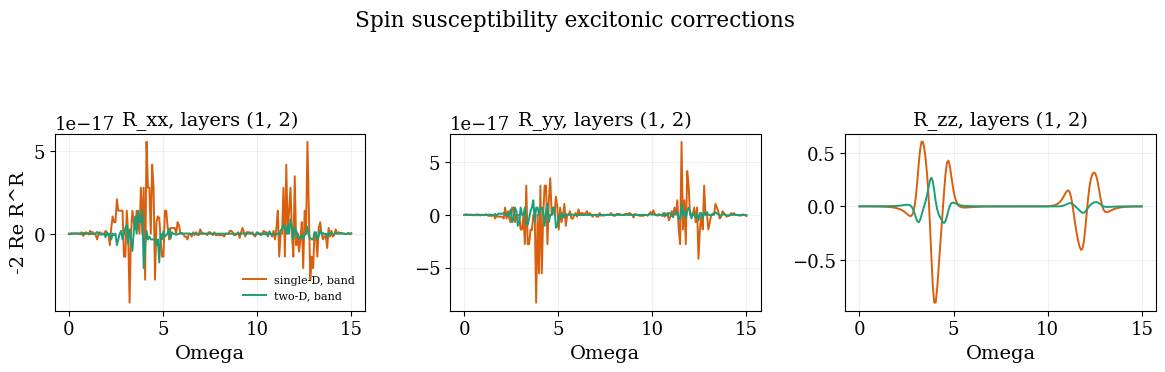

In [12]:
# Quick-look grids for the frequency-domain spin susceptibility figure.
Lχ = 100
Ωχ_min, Ωχ_max, NΩχ = 0.0, 15.0, 201
ωχ_min, ωχ_max, Nωχ = -15.0, 15.0, 321  # only used when vertex_methodχ = :langreth
ηDχ = 0.52#ηΩ
ηΛχ = 0.52#ηΩ

ksχ = collect(range(-π, stop=π - 2π/Lχ, length=Lχ))
Ωsχ = collect(range(Ωχ_min, Ωχ_max, length=NΩχ))
ωsχ = collect(range(ωχ_min, ωχ_max, length=Nωχ))

layer_pairχ = (1, 2)
vertex_methodχ = :band
plot_partχ = real#imag#real  # use imag for the absorptive part
ylabel_partχ = plot_partχ === real ? "Re" : "Im"

println("Computing D, R_1D, and R_2D for layer pair " * string(layer_pairχ) * "...")
# @time Rbareχ, layer_dataχ = spin_susceptibility_bare_band(Ωsχ, ksχ, θ)
@time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
D_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)

if vertex_methodχ == :band
    @time R1Ddiagχ, Λdiagχ, dataΛχ = spin_susceptibility_oneD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
elseif vertex_methodχ == :langreth
    @time R1Ddiagχ, Λdiagχ = spin_susceptibility_oneD_diag_explicit_langreth(Dχ, Ωsχ, ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
else
    error("Unknown vertex_methodχ: " * string(vertex_methodχ))
end
Λdiag_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=layer_pairχ, method=vertex_methodχ)

@time R2Ddiagχ, R2Dχ, Λoneχ, dataΛoneχ = spin_susceptibility_twoD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
Λone_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, method=:band)

fig, axs = subplots(1, 3, figsize=(12.0, 3.8), sharex=true)
for a in 1:3
    ax = axs[a]
    # Abare = [-2 * imag(Rbareχ[layer_pairχ[1], layer_pairχ[2], a, a, iΩ]) for iΩ in axes(Rbareχ, 5)]
    A1D = [-2 * plot_partχ(R1Ddiagχ[a, iΩ]) for iΩ in axes(R1Ddiagχ, 2)]
    A2D = [-2 * plot_partχ(R2Ddiagχ[a, iΩ]) for iΩ in axes(R2Ddiagχ, 2)]
    Atotal = A1D .+ A2D

    #ax.plot(Ωsχ, Abare, color="0.45", lw=1.5, label="bare")
    ax.plot(Ωsχ, A1D, color="#d95f0e", lw=1.4, label="single-D, " * string(vertex_methodχ))
    ax.plot(Ωsχ, A2D, color="#1b9e77", lw=1.4, label="two-D, band")
    #ax.plot(Ωsχ, Atotal, color="black", lw=1.8, label="single-D + two-D")
    ax.set_title("R_" * spin_labels[a] * spin_labels[a] * ", layers " * string(layer_pairχ))
    ax.set_xlabel("Omega")
    ax.grid(alpha=0.18)
end
axs[1].set_ylabel("-2 " * ylabel_partχ * " R^R")
axs[1].legend(frameon=false, fontsize=8)
fig.suptitle("Spin susceptibility excitonic corrections")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## Diagnostic: exciton propagator $D^R$

This plot checks the collective excitonic propagator used in the single-$D$ spin-susceptibility correction. The left panel shows the channel-resolved spectral weight $-2\,\mathrm{Im}\,D^R_{\mu\mu}(\Omega)$. The right panel shows the eigenvalues of $D^R(\Omega)$; sharp features or sign changes here indicate collective excitonic resonances.


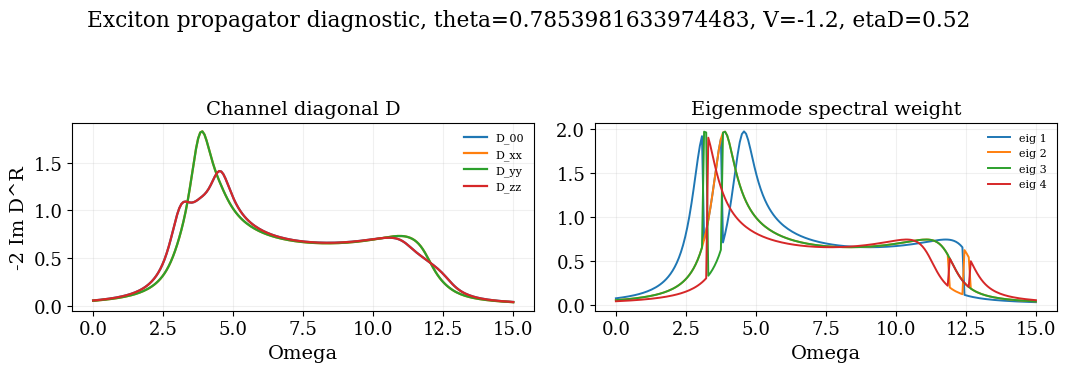

In [13]:
if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

Ddiag_spectral = [-2 * imag(Dχ[μ, μ, iΩ]) for μ in 1:4, iΩ in axes(Dχ, 3)]
Deig_spectral = zeros(Float64, 4, length(Ωsχ))
for iΩ in axes(Dχ, 3)
    vals = eigvals(Dχ[:, :, iΩ])
    order = sortperm(abs.(vals), rev=true)
    Deig_spectral[:, iΩ] .= [-2 * imag(vals[j]) for j in order]
end

fig, axs = subplots(1, 2, figsize=(11.0, 3.8), sharex=true)
for μ in 1:4
    axs[1].plot(Ωsχ, Ddiag_spectral[μ, :], lw=1.6, label="D_" * channel_labels[μ] * channel_labels[μ])
    axs[2].plot(Ωsχ, Deig_spectral[μ, :], lw=1.4, label="eig " * string(μ))
end
axs[1].set_title("Channel diagonal D")
axs[2].set_title("Eigenmode spectral weight")
for ax in axs
    ax.set_xlabel("Omega")
    ax.grid(alpha=0.18)
    ax.legend(frameon=false, fontsize=8)
end
axs[1].set_ylabel("-2 Im D^R")
fig.suptitle("Exciton propagator diagnostic, theta=" * string(θ) * ", V=" * string(V) * ", etaD=" * string(ηDχ))
fig.tight_layout(rect=(0, 0, 1, 0.90))


## Diagnostic: two-spin vertex $\Lambda^R$

This plot checks the reduced two-spin vertex entering the current layer-pair response. For each spin component $a=x,y,z$, the first three panels show the channel trace $\sum_\mu \Lambda^{ll',aa,R}_{\mu\mu}(\Omega)$. The last panel shows its channel Frobenius norm, useful for identifying where the vertex itself has large structure before contraction with $D^R$.

This diagnostic is not itself an observable. The trace can look jagged because the vertex contains higher-order denominators than $\Pi^R$ and is sensitive to finite-$k$ resolution and the broadening $\eta$. If this plot looks noisy, first compare against the norm and then increase `Lχ` or `ηΩ`.


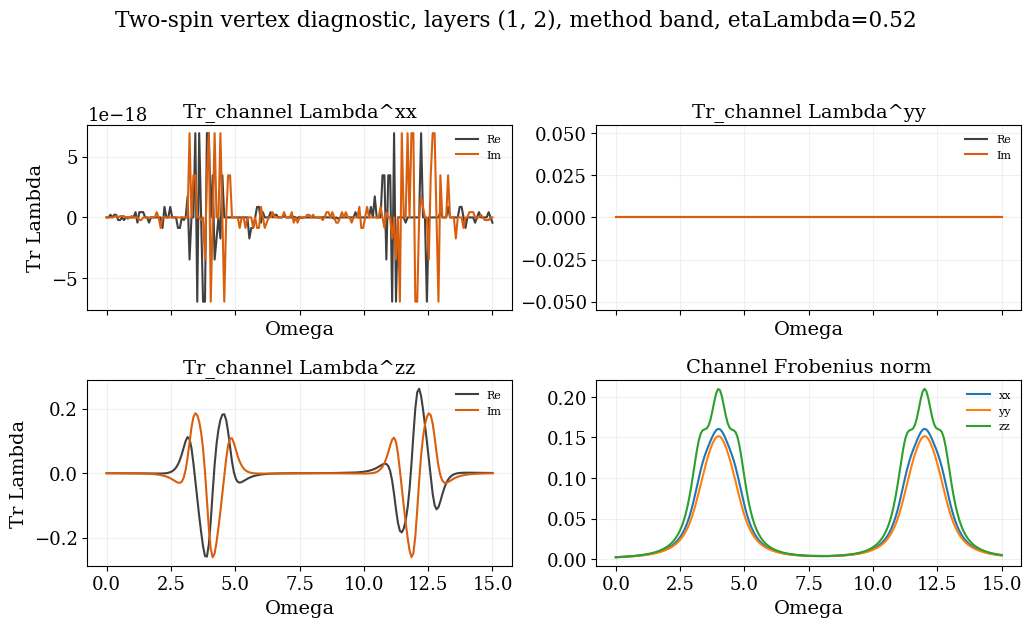

In [16]:
if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end
if !(@isdefined(ηΛχ))
    ηΛχ = ηΩ
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

Λdiag_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=layer_pairχ, method=vertex_methodχ)
if !(@isdefined(Λdiagχ)) || !(@isdefined(Λdiag_metaχ)) || Λdiag_metaχ != Λdiag_meta_currentχ
    if vertex_methodχ == :band
        @time R1Ddiagχ, Λdiagχ, dataΛχ = spin_susceptibility_oneD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
    elseif vertex_methodχ == :langreth
        @time R1Ddiagχ, Λdiagχ = spin_susceptibility_oneD_diag_explicit_langreth(Dχ, Ωsχ, ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
    else
        error("Unknown vertex_methodχ: " * string(vertex_methodχ))
    end
    Λdiag_metaχ = Λdiag_meta_currentχ
end

Λtrace = zeros(ComplexF64, 3, length(Ωsχ))
Λnorm = zeros(Float64, 3, length(Ωsχ))
for a in 1:3, iΩ in axes(Λdiagχ, 4)
    Λtrace[a, iΩ] = sum(Λdiagχ[a, μ, μ, iΩ] for μ in 1:4)
    Λnorm[a, iΩ] = sqrt(sum(abs2, Λdiagχ[a, :, :, iΩ]))
end

fig, axs = subplots(2, 2, figsize=(10.5, 6.4), sharex=true)
axs_flat = [axs[1, 1], axs[1, 2], axs[2, 1], axs[2, 2]]
for a in 1:3
    ax = axs_flat[a]
    ax.plot(Ωsχ, real.(Λtrace[a, :]), color="0.25", lw=1.5, label="Re")
    ax.plot(Ωsχ, imag.(Λtrace[a, :]), color="#d95f0e", lw=1.5, label="Im")
    ax.set_title("Tr_channel Lambda^" * spin_labels[a] * spin_labels[a])
    ax.grid(alpha=0.18)
    ax.legend(frameon=false, fontsize=8)
end
for a in 1:3
    axs_flat[4].plot(Ωsχ, Λnorm[a, :], lw=1.5, label=spin_labels[a] * spin_labels[a])
end
axs_flat[4].set_title("Channel Frobenius norm")
axs_flat[4].grid(alpha=0.18)
axs_flat[4].legend(frameon=false, fontsize=8)
for ax in axs_flat
    ax.set_xlabel("Omega")
end
axs_flat[1].set_ylabel("Tr Lambda")
axs_flat[3].set_ylabel("Tr Lambda")
fig.suptitle("Two-spin vertex diagnostic, layers " * string(layer_pairχ) * ", method " * string(vertex_methodχ) * ", etaLambda=" * string(ηΛχ))
fig.tight_layout(rect=(0, 0, 1, 0.93))


## Explorer: individual components of $\Lambda^R$

Use this cell to inspect specific channel components $\Lambda^{ll',aa,R}_{\mu\nu}(\Omega)$ rather than only traces or norms. The parameters at the top are independent from the previous figures, so you can quickly change the layer pair, spin component, channels, vertex broadening `ηΛλ`, and frequency/momentum resolution.


Computing Lambda components with method band, layers (1, 2), spin zz, etaLambda 0.25...
 42.186885 seconds (1.24 G allocations: 28.018 GiB, 27.25% gc time, 0.04% compilation time)


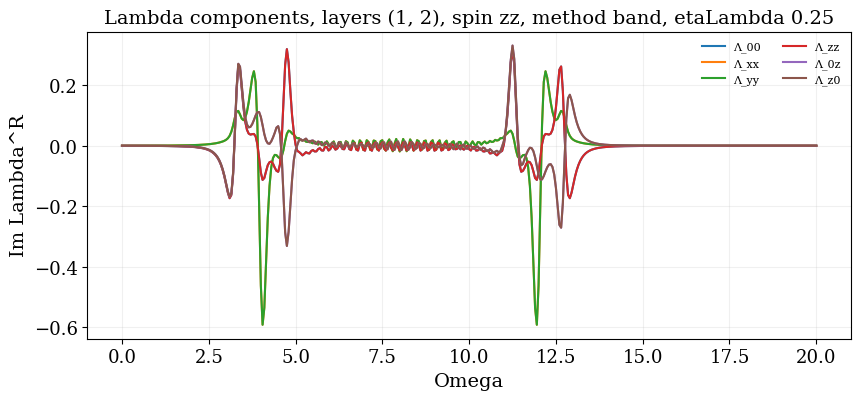

In [17]:
# -----------------------------
# Editable parameters for Lambda component exploration
# -----------------------------
lambda_method = :band          # :band or :langreth
lambda_layer_pair = (1, 2)    # (1,1), (1,2), (2,1), or (2,2)
lambda_spin_component = 3     # 1=x, 2=y, 3=z; this plots a=a
lambda_channel_pairs = [(1, 1), (2, 2), (3, 3), (4, 4), (1, 4), (4, 1)]
lambda_part = imag            # real, imag, or abs
lambda_part_label = lambda_part === real ? "Re" : lambda_part === imag ? "Im" : "Abs"

Lλ = 120
Ωλ_min, Ωλ_max, NΩλ = 0.0, 20.0, 401
ηΛλ = ηΩ

# Only used for lambda_method = :langreth.
ωλ_min, ωλ_max, Nωλ = -15.0, 15.0, 321

ksλ = collect(range(-π, stop=π - 2π/Lλ, length=Lλ))
Ωsλ = collect(range(Ωλ_min, Ωλ_max, length=NΩλ))
ωsλ = collect(range(ωλ_min, ωλ_max, length=Nωλ))

println("Computing Lambda components with method " * string(lambda_method) *
        ", layers " * string(lambda_layer_pair) *
        ", spin " * spin_labels[lambda_spin_component] * spin_labels[lambda_spin_component] *
        ", etaLambda " * string(ηΛλ) * "...")

if lambda_method == :band
    @time Λλ, dataΛλ = lambda_layerpair_diag_band(Ωsλ, ksλ, θ; layer_pair=lambda_layer_pair, η=ηΛλ)
elseif lambda_method == :langreth
    @time Λλ = lambda_layerpair_diag_explicit_langreth(Ωsλ, ωsλ, ksλ, θ; layer_pair=lambda_layer_pair, η=ηΛλ)
else
    error("Unknown lambda_method: " * string(lambda_method))
end

fig, ax = subplots(1, 1, figsize=(8.8, 4.2))
aλ = lambda_spin_component
for (μ, ν) in lambda_channel_pairs
    y = [lambda_part(Λλ[aλ, μ, ν, iΩ]) for iΩ in axes(Λλ, 4)]
    label = "Λ_" * channel_labels[μ] * channel_labels[ν]
    ax.plot(Ωsλ, y, lw=1.5, label=label)
end
ax.set_xlabel("Omega")
ax.set_ylabel(lambda_part_label * " Lambda^R")
ax.set_title("Lambda components, layers " * string(lambda_layer_pair) *
             ", spin " * spin_labels[aλ] * spin_labels[aλ] *
             ", method " * string(lambda_method) * ", etaLambda " * string(ηΛλ))
ax.grid(alpha=0.18)
ax.legend(frameon=false, fontsize=8, ncol=2)
fig.tight_layout()


## Charge-spin source extension

To include charge response we extend the external-source index from $a=x,y,z$ to $A=0,x,y,z$. The `0` component is a scalar layer source, implemented with the same Hamiltonian convention as the chemical potential, so

$$\frac{\partial h_l}{\partial \phi_l^0}=-\sigma^0.$$

The spin components keep the magnetization-source convention already used above, $\partial h_l/\partial M_l^a$. Therefore the extended tensor contains charge-charge ($00$), charge-spin ($0a,a0$), and spin-spin ($ab$) components in one plot.


### What the charge-spin source functions build

The next code cell defines the source basis $A=0,x,y,z$ and the vertex blocks used by the one-$D$ and two-$D$ corrections. For each external frequency it evaluates the analytic source-differentiated vertex in the eigenbasis of the two layer Hamiltonians, then contracts that vertex with the exciton propagator $D^R_{\mu\nu}$.

The returned tensors keep the indices ordered as `A, B, Ω` for the susceptibility and `A, B, μ, ν, Ω` for the vertex. The `0` row/column is the scalar charge source; `x,y,z` are spin sources. This is why the following plots can show charge, spin, and mixed charge-spin responses with the same code path.


In [14]:
charge_spin_labels = ["0", "x", "y", "z"]

function dh_dcharge_spin_source(layer::Int, comp::Int)
    # comp=1 is the scalar layer source, equivalent to the chemical-potential convention h -> h - phi0*sigma0.
    comp == 1 && return -σ0
    return dh_dM(layer, comp - 1)
end

function lambda_layerpair_charge_spin_full_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    data = diagonalize_layers(ks, θ)
    Λ = zeros(ComplexF64, 4, 4, 4, 4, length(Ωs))
    dh1 = [dh_dcharge_spin_source(1, A) for A in 1:4]
    dh2 = [dh_dcharge_spin_source(2, A) for A in 1:4]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[A] * U1 for A in 1:4]
        dh2e = [U2' * dh2[A] * U2 for A in 1:4]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for A in 1:4, B in 1:4, μ in 1:4, ν in 1:4
                acc = zero(ComplexF64)
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1A = dh1e[A]
                h1B = dh1e[B]
                h2A = dh2e[A]
                h2B = dh2e[B]

                if l == 1 && lp == 1
                    for p in 1:2, r in 1:2, s in 1:2, q in 1:2
                        coeff = dd2_x(Ω, E1[p], E1[r], E1[s], E2[q], η)
                        acc += coeff * (h1B[p, r] * h1A[r, s] + h1A[p, r] * h1B[r, s]) * Γμ[s, q] * conj(Γν[p, q])
                    end
                elseif l == 2 && lp == 2
                    for p in 1:2, q in 1:2, r in 1:2, s in 1:2
                        coeff = dd2_y(Ω, E1[p], E2[q], E2[r], E2[s], η)
                        acc += coeff * Γμ[p, q] * (h2A[q, r] * h2B[r, s] + h2B[q, r] * h2A[r, s]) * conj(Γν[p, s])
                    end
                elseif l == 1 && lp == 2
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1A[p, r] * Γμ[r, q] * h2B[q, s] * conj(Γν[p, s])
                    end
                else
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1B[p, r] * Γμ[r, q] * h2A[q, s] * conj(Γν[p, s])
                    end
                end

                Λ[A, B, μ, ν, iΩ] += acc / length(ks)
            end
        end
    end

    return Λ, data
end

function contract_singleD_charge_spin_full(D, Λ; prefactor=-1im)
    R = zeros(ComplexF64, 4, 4, size(D, 3))

    for A in 1:4, B in 1:4, iΩ in axes(D, 3)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λ[A, B, ν, μ, iΩ]
        end
        R[A, B, iΩ] = prefactor * acc
    end

    return R
end

function spin_susceptibility_oneD_charge_spin_full_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im)
    Λ, data = lambda_layerpair_charge_spin_full_band(Ωs, ks, θ; layer_pair=layer_pair, η=η)
    R = contract_singleD_charge_spin_full(D, Λ; prefactor=prefactor)
    return R, Λ, data
end

function lambda_one_charge_spin_layers_band(Ωs, ks, θ; η=ηΩ)
    data = diagonalize_layers(ks, θ)
    Λone = zeros(ComplexF64, 2, 4, 4, 4, length(Ωs))
    dh1 = [dh_dcharge_spin_source(1, A) for A in 1:4]
    dh2 = [dh_dcharge_spin_source(2, A) for A in 1:4]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[A] * U1 for A in 1:4]
        dh2e = [U2' * dh2[A] * U2 for A in 1:4]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for A in 1:4, μ in 1:4, ν in 1:4
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1A = dh1e[A]
                h2A = dh2e[A]

                acc1 = zero(ComplexF64)
                for p in 1:2, r in 1:2, q in 1:2
                    coeff = dd1_x(Ω, E1[p], E1[r], E2[q], η)
                    acc1 += coeff * h1A[p, r] * Γμ[r, q] * conj(Γν[p, q])
                end

                acc2 = zero(ComplexF64)
                for p in 1:2, q in 1:2, r in 1:2
                    coeff = dd1_y(Ω, E1[p], E2[q], E2[r], η)
                    acc2 += coeff * Γμ[p, q] * h2A[q, r] * conj(Γν[p, r])
                end

                Λone[1, A, μ, ν, iΩ] += acc1 / length(ks)
                Λone[2, A, μ, ν, iΩ] += acc2 / length(ks)
            end
        end
    end

    return Λone, data
end

function contract_twoD_charge_spin(D, Λone; prefactor=1im)
    R2D = zeros(ComplexF64, 2, 2, 4, 4, size(D, 3))

    @views for iΩ in axes(D, 3), l in 1:2, lp in 1:2, A in 1:4, B in 1:4
        R2D[l, lp, A, B, iΩ] = prefactor * tr(D[:, :, iΩ] * Λone[l, A, :, :, iΩ] * D[:, :, iΩ] * Λone[lp, B, :, :, iΩ])
    end

    return R2D
end

function spin_susceptibility_twoD_charge_spin_band(D, Ωs, ks, θ; η=ηΩ, prefactor=1im)
    Λone, data = lambda_one_charge_spin_layers_band(Ωs, ks, θ; η=η)
    R2D = contract_twoD_charge_spin(D, Λone; prefactor=prefactor)
    return R2D, Λone, data
end;


## Diagnostic: full charge-spin tensor $R^{AB}_{ll'}$

This figure extends the spin-susceptibility tensor to $A,B=0,x,y,z$. For one selected layer pair it plots all entries of the excitonic correction

$$-2\,\mathrm{Im}\,R^{R,AB}_{ll'}(\Omega).$$

The $00$ panel is the charge-charge response in the scalar-source convention. The $0a$ and $a0$ panels are charge-spin mixed responses, and the $ab$ block is the spin-spin tensor considered above. Mixed components are signed diagnostics and are not required to be positive component by component.

Use `tensor_sourceχ = :oneD`, `:twoD`, or `:sum` to choose which excitonic contribution is plotted.


### Reading the fixed-angle tensor plot

This cell uses the current global angle `θ` and Hamiltonian parameters. It recomputes $D^R$, $\Lambda^R$, and the selected correction only when the metadata has changed, so rerunning the plot cell is cheap after the first pass.

With `tensor_sourceχ = :oneD` you see the diagram containing one exciton propagator. With `:twoD` you see the two-vertex/two-$D$ contribution. With `:sum` both are added. The default plotted quantity is $-2\,\mathrm{Im}\,R^R$; off-diagonal charge-spin or spin-spin components are signed response components, not standalone positive spectral functions.


 95.370573 seconds (2.75 G allocations: 62.451 GiB, 26.29% gc time, 0.56% compilation time)
 15.709992 seconds (435.98 M allocations: 10.188 GiB, 23.23% gc time, 3.29% compilation time)


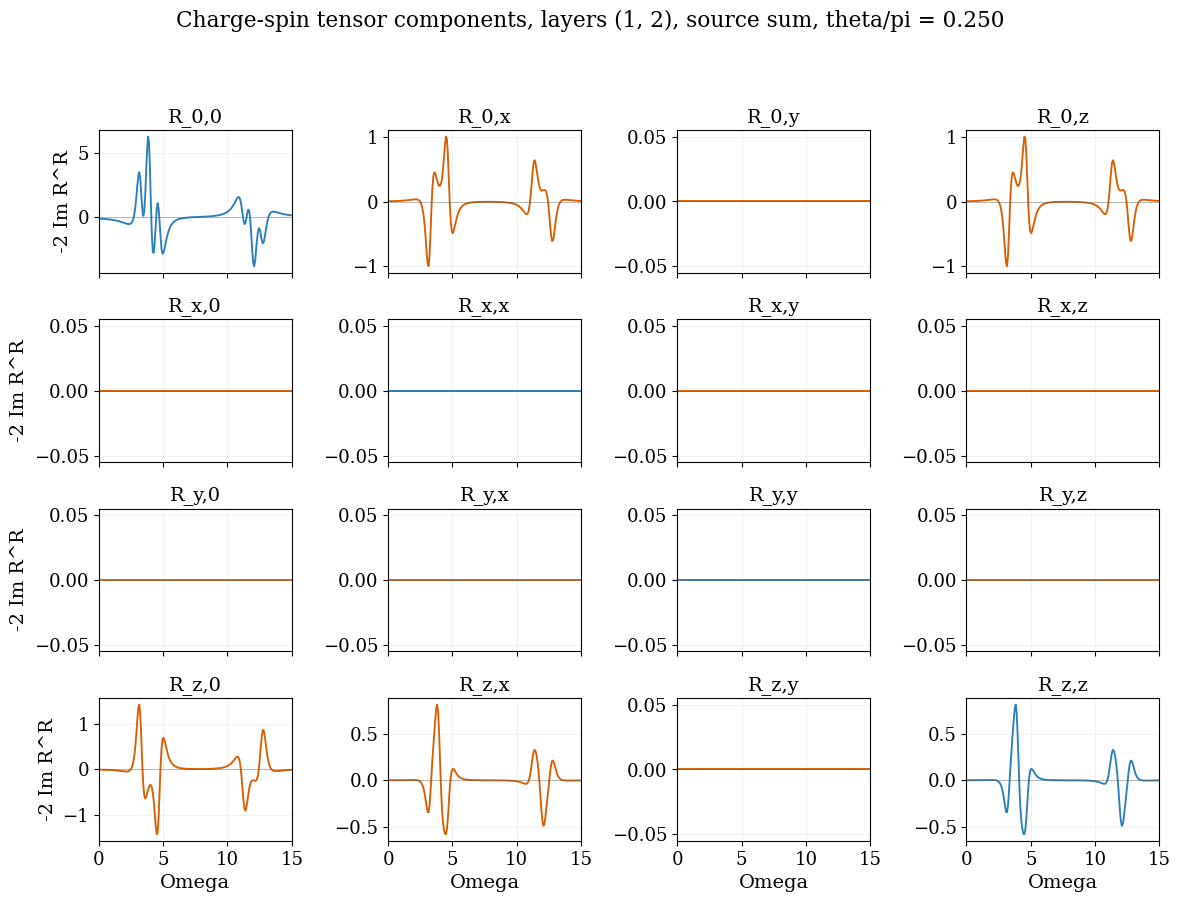

In [19]:
# -----------------------------
# Editable parameters for full charge-spin tensor component plot
# -----------------------------
tensor_layer_pairχ = (1,2)#layer_pairχ      # e.g. (1, 2)
tensor_sourceχ = :sum                 # :oneD, :twoD, or :sum
tensor_partχ = imag                   # imag gives the absorptive response; use real or abs if needed
tensor_part_labelχ = tensor_partχ === real ? "Re" : tensor_partχ === imag ? "Im" : "Abs"
tensor_zero_tolχ = 1e-10              # components below this are shown as exact zero
tensor_xlimχ = (first(Ωsχ), last(Ωsχ))

if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end
if !(@isdefined(ηΛχ))
    ηΛχ = ηΩ
end

function clean_charge_spin_tensor_line(y; tol=tensor_zero_tolχ)
    out = collect(y)
    if maximum(abs.(out)) < tol
        out .= 0.0
    else
        out = [abs(v) < tol ? 0.0 : v for v in out]
    end
    return out
end

function project_charge_spin_component(z, part)
    part === abs && return abs(z)
    return -2 * part(z)
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

R1Dcs_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=tensor_layer_pairχ, method=:band, source=:charge_spin)
if !(@isdefined(R1Dcsχ)) || !(@isdefined(R1Dcs_metaχ)) || R1Dcs_metaχ != R1Dcs_meta_currentχ
    @time R1Dcsχ, Λfullcsχ, dataΛfullcsχ = spin_susceptibility_oneD_charge_spin_full_band(Dχ, Ωsχ, ksχ, θ; layer_pair=tensor_layer_pairχ, η=ηΛχ)
    R1Dcs_metaχ = R1Dcs_meta_currentχ
end

R2Dcs_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, method=:band, source=:charge_spin)
if !(@isdefined(R2Dcsχ)) || !(@isdefined(R2Dcs_metaχ)) || R2Dcs_metaχ != R2Dcs_meta_currentχ
    @time R2Dcsχ, Λonecsχ, dataΛonecsχ = spin_susceptibility_twoD_charge_spin_band(Dχ, Ωsχ, ksχ, θ; η=ηΛχ)
    R2Dcs_metaχ = R2Dcs_meta_currentχ
end

lχ, lpχ = tensor_layer_pairχ
R2Dcslayerχ = R2Dcsχ[lχ, lpχ, :, :, :]
if tensor_sourceχ == :oneD
    Rtensorχ = R1Dcsχ
elseif tensor_sourceχ == :twoD
    Rtensorχ = R2Dcslayerχ
elseif tensor_sourceχ == :sum
    Rtensorχ = R1Dcsχ .+ R2Dcslayerχ
else
    error("Unknown tensor_sourceχ: " * string(tensor_sourceχ))
end

ylabel_tensorχ = tensor_partχ === abs ? "Abs R^R" : "-2 " * tensor_part_labelχ * " R^R"

fig, axs = subplots(4, 4, figsize=(12.0, 9.2), sharex=true)
for A in 1:4, B in 1:4
    ax = axs[A, B]
    y = clean_charge_spin_tensor_line([project_charge_spin_component(Rtensorχ[A, B, iΩ], tensor_partχ) for iΩ in axes(Rtensorχ, 3)])
    ax.plot(Ωsχ, y, color=(A == B ? "#2c7fb8" : "#d95f02"), lw=1.35)
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax.set_title("R_" * charge_spin_labels[A] * "," * charge_spin_labels[B])
    ax.grid(alpha=0.16)
    ax.set_xlim(tensor_xlimχ...)
    if A == 4
        ax.set_xlabel("Omega")
    end
    if B == 1
        ax.set_ylabel(ylabel_tensorχ)
    end
end
fig.suptitle("Charge-spin tensor components, layers " * string(tensor_layer_pairχ) *
             ", source " * string(tensor_sourceχ) *
             ", theta/pi = " * @sprintf("%.3f", θ/π))
fig.tight_layout(rect=(0, 0, 1, 0.94))


## Angle-resolved charge-spin tensor maps

This is the angle-sweep version of the fixed-angle charge-spin tensor plot. For each magnetic angle we compute the selected excitonic contribution and plot

$$-2\,\mathrm{Im}\,R^{R,AB}_{ll'}(\Omega;\theta),\qquad A,B=0,x,y,z.$$

Each angle is independent, so the compute cell can parallelize over angles with `Threads.@threads`. This uses Julia threads from the current kernel; if `Threads.nthreads()` is 1, the same code runs serially. Restart Julia with multiple threads for actual parallel speedup.


### Angle sweep: computation

The next cell repeats the fixed-angle tensor calculation for a list of angles $\theta\in[0,\pi]$. Each angle is independent: no result at one $\theta$ feeds another. If the Julia kernel was started with more than one thread, `Threads.@threads` distributes the outer angle loop across those threads; otherwise the cell runs serially with identical output.

The variables `Lθχ`, `NΩθχ`, and `Nθχ` are independent from the fixed-angle grid. Keep them modest while exploring the structure, then increase them for a production-quality map.


In [20]:
# -----------------------------
# Editable parameters for angle-resolved charge-spin tensor computation
# -----------------------------
angle_tensor_layer_pairχ = @isdefined(tensor_layer_pairχ) ? tensor_layer_pairχ : layer_pairχ  # e.g. (1, 2)
angle_tensor_sourceχ = @isdefined(tensor_sourceχ) ? tensor_sourceχ : :sum                      # :oneD, :twoD, or :sum
angle_use_threadsχ = true                          # parallelize angles if Julia has more than one thread

# Independent grid for the angular sweep. Increase these for production figures.
Lθχ = 60
Ωθχ_min, Ωθχ_max, NΩθχ = 0.0, 15.0, 121
Nθχ = 13
ηDθχ = @isdefined(ηDχ) ? ηDχ : ηΩ
ηΛθχ = @isdefined(ηΛχ) ? ηΛχ : ηΩ

ksθχ = collect(range(-π, stop=π - 2π/Lθχ, length=Lθχ))
Ωsθχ = collect(range(Ωθχ_min, Ωθχ_max, length=NΩθχ))
θsχ = collect(range(0.0, π, length=Nθχ))

function solve_angle_charge_spin_tensorχ(θval, Ωs_local, ks_local;
                                         Vval=V, ηD=ηΩ, ηΛ=ηΩ,
                                         layer_pair=(1, 1), source=:sum)
    source in (:oneD, :twoD, :sum) || error("Unknown angle tensor source: " * string(source))

    Dθ, Πθ, dataDθ = precompute_exciton_D(Ωs_local, ks_local, θval; V=Vval, η=ηD)
    R1Dθ = zeros(ComplexF64, 4, 4, length(Ωs_local))
    R2Dlayerθ = zeros(ComplexF64, 4, 4, length(Ωs_local))

    if source in (:oneD, :sum)
        R1Dθ, Λfullθ, dataΛfullθ = spin_susceptibility_oneD_charge_spin_full_band(Dθ, Ωs_local, ks_local, θval;
                                                                                   layer_pair=layer_pair, η=ηΛ)
    end

    if source in (:twoD, :sum)
        R2Dθ, Λoneθ, dataΛoneθ = spin_susceptibility_twoD_charge_spin_band(Dθ, Ωs_local, ks_local, θval; η=ηΛ)
        lθ, lpθ = layer_pair
        R2Dlayerθ .= R2Dθ[lθ, lpθ, :, :, :]
    end

    Rθ = source == :oneD ? R1Dθ : source == :twoD ? R2Dlayerθ : R1Dθ .+ R2Dlayerθ
    return (; θ=θval, R=Rθ, R1D=R1Dθ, R2D=R2Dlayerθ)
end

function run_charge_spin_angle_sweepχ(θs_local, Ωs_local, ks_local;
                                      Vval=V, ηD=ηΩ, ηΛ=ηΩ,
                                      layer_pair=(1, 1), source=:sum,
                                      use_threads=true)
    results = Vector{Any}(undef, length(θs_local))
    threaded = use_threads && Threads.nthreads() > 1

    if threaded
        Threads.@threads for iθ in eachindex(θs_local)
            results[iθ] = solve_angle_charge_spin_tensorχ(θs_local[iθ], Ωs_local, ks_local;
                                                          Vval=Vval, ηD=ηD, ηΛ=ηΛ,
                                                          layer_pair=layer_pair, source=source)
        end
    else
        for iθ in eachindex(θs_local)
            println(iθ)
            results[iθ] = solve_angle_charge_spin_tensorχ(θs_local[iθ], Ωs_local, ks_local;
                                                          Vval=Vval, ηD=ηD, ηΛ=ηΛ,
                                                          layer_pair=layer_pair, source=source)
        end
    end

    return results
end

angle_sweep_meta_currentχ = (Nθ=length(θsχ), NΩ=length(Ωsθχ), L=length(ksθχ),
                             θmin=first(θsχ), θmax=last(θsχ), V=V,
                             ηD=ηDθχ, ηΛ=ηΛθχ, μ1=μ1, μ2=μ2,
                             layer_pair=angle_tensor_layer_pairχ,
                             source=angle_tensor_sourceχ,
                             version=:charge_spin_angle_tensor_v1)

println("Angle sweep charge-spin tensor: Nθ=$(length(θsχ)), NΩ=$(length(Ωsθχ)), L=$(length(ksθχ)), source=$(angle_tensor_sourceχ)")
println("Julia threads available: $(Threads.nthreads()); threaded angles = $(angle_use_threadsχ && Threads.nthreads() > 1)")

if !(@isdefined(angle_sweepχ)) || !(@isdefined(angle_sweep_metaχ)) || angle_sweep_metaχ != angle_sweep_meta_currentχ
    @time angle_sweepχ = run_charge_spin_angle_sweepχ(θsχ, Ωsθχ, ksθχ;
                                                      Vval=V, ηD=ηDθχ, ηΛ=ηΛθχ,
                                                      layer_pair=angle_tensor_layer_pairχ,
                                                      source=angle_tensor_sourceχ,
                                                      use_threads=angle_use_threadsχ)
    angle_sweep_metaχ = angle_sweep_meta_currentχ
else
    println("Using cached angle_sweepχ")
end;


Angle sweep charge-spin tensor: Nθ=13, NΩ=121, L=60, source=sum
Julia threads available: 40; threaded angles = true
153.804820 seconds (15.01 G allocations: 341.896 GiB, 61.54% gc time, 1.60% compilation time)


### Angle sweep: maps

This plotting cell does not recompute the susceptibility; it only reshapes the stored `angle_sweepχ` data. The horizontal axis is frequency $\Omega$ and the vertical axis is $\theta/\pi$.

For signed quantities such as `real` or `imag`, the color scale is centered at zero so red and blue indicate opposite response signs. Components below `angle_tensor_zero_tolχ` are displayed as exact zero to suppress numerical noise in symmetry-forbidden panels.


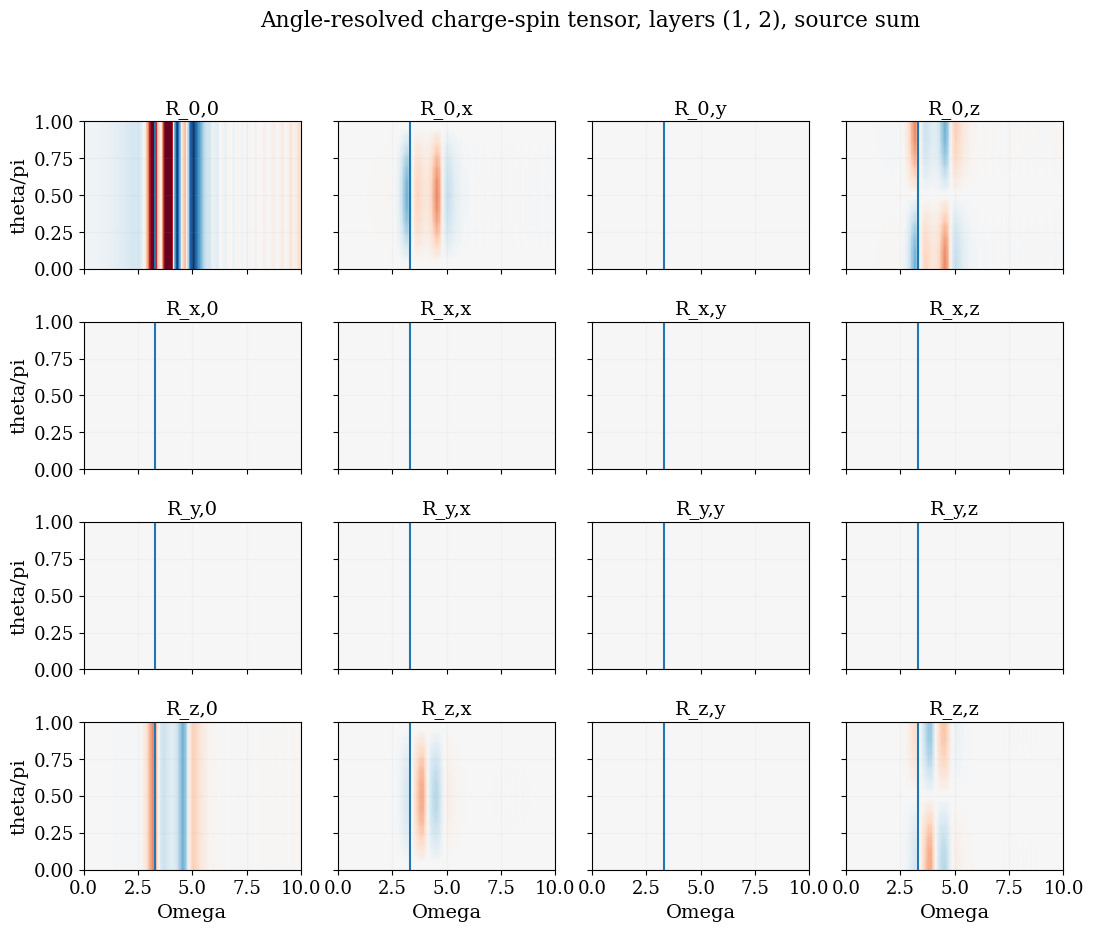

In [36]:
# -----------------------------
# Angle-resolved full charge-spin tensor maps
# -----------------------------
angle_tensor_partχ = imag#@isdefined(tensor_partχ) ? tensor_partχ : imag  # real, imag, or abs
angle_tensor_part_labelχ = angle_tensor_partχ === real ? "Re" : angle_tensor_partχ === imag ? "Im" : "Abs"
angle_tensor_zero_tolχ = @isdefined(tensor_zero_tolχ) ? tensor_zero_tolχ : 1e-10
angle_tensor_xlimχ = (first(Ωsθχ), min(10.0, last(Ωsθχ)))

function project_charge_spin_angle_componentχ(z, part)
    part === abs && return abs(z)
    return -2 * part(z)
end

function clean_charge_spin_angle_mapχ(A; tol=angle_tensor_zero_tolχ)
    out = copy(A)
    if maximum(abs.(out)) < tol
        out .= 0.0
    else
        out[abs.(out) .< tol] .= 0.0
    end
    return out
end

if !(@isdefined(angle_sweepχ))
    error("Run the angle-sweep compute cell before plotting the maps.")
end

angle_component_mapsχ = Matrix{Array{Float64, 2}}(undef, 4, 4)
for A in 1:4, B in 1:4
    component = reduce(hcat, [[project_charge_spin_angle_componentχ(sol.R[A, B, iΩ], angle_tensor_partχ)
                               for iΩ in axes(sol.R, 3)] for sol in angle_sweepχ])
    angle_component_mapsχ[A, B] = clean_charge_spin_angle_mapχ(permutedims(component))
end

all_angle_componentsχ = vcat([vec(angle_component_mapsχ[A, B]) for A in 1:4 for B in 1:4]...)
vmax_angle_tensorχ = maximum(abs.(all_angle_componentsχ))
vmax_angle_tensorχ = vmax_angle_tensorχ > 0 ? vmax_angle_tensorχ : 1.0

if angle_tensor_partχ === abs
    cmap_angle_tensorχ = "magma"
    vmin_angle_tensorχ = 0.0
    vmax_plot_angle_tensorχ = vmax_angle_tensorχ
    colorbar_labelχ = "Abs R_AB"
else
    cmap_angle_tensorχ = "RdBu_r"
    vmin_angle_tensorχ = -vmax_angle_tensorχ
    vmax_plot_angle_tensorχ = vmax_angle_tensorχ
    colorbar_labelχ = "-2 " * angle_tensor_part_labelχ * " R_AB"
end

fig, axs = subplots(4, 4, figsize=(12.0, 9.5), sharex=true, sharey=true)
θ_over_piχ = θsχ ./ π
for A in 1:4, B in 1:4
    ax = axs[A, B]
    ax.axvline(3.3)
    img = ax.imshow(angle_component_mapsχ[A, B]; origin="lower", aspect="auto",
                    extent=(first(Ωsθχ), last(Ωsθχ), first(θ_over_piχ), last(θ_over_piχ)),
                    cmap=cmap_angle_tensorχ, vmin=-3,vmax=3)#vmin=vmin_angle_tensorχ, vmax=vmax_plot_angle_tensorχ)
    ax.set_xlim(angle_tensor_xlimχ...)
    ax.set_title("R_" * charge_spin_labels[A] * "," * charge_spin_labels[B])
    ax.grid(alpha=0.08)
    if A == 4
        ax.set_xlabel("Omega")
    end
    if B == 1
        ax.set_ylabel("theta/pi")
        
    end
end
#ax.set_vline(3.3)
#fig.colorbar(img, ax=vec(axs), shrink=0.82, label=colorbar_labelχ)
fig.suptitle("Angle-resolved charge-spin tensor, layers " * string(angle_tensor_layer_pairχ) *
             ", source " * string(angle_tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 0.92, 0.95))


## Time-domain charge-spin susceptibility

This figure transforms the retarded charge-spin susceptibility back to time for three representative magnetic angles,

$$\theta=0,\pi/2,\pi.$$

For each angle we first compute the selected excitonic contribution on an independent symmetric frequency grid and then use

$$R^{R,AB}_{ll'}(t;\theta)\simeq\int_{\Omega_{\min}}^{\Omega_{\max}}\frac{d\Omega}{2\pi}\,W(\Omega)\,e^{-i\Omega t}R^{R,AB}_{ll'}(\Omega;\theta).$$

The optional Hann window $W(\Omega)$ smooths the finite frequency cutoff. Each angle is independent, so the frequency-domain part can use `Threads.@threads` when the Julia kernel has more than one thread.


### Time response: computation

The next cell computes $R^R(\Omega)$ on a symmetric frequency grid and performs the inverse transform

$$R^{R,AB}_{ll'}(t)=\int\frac{d\Omega}{2\pi}\,W(\Omega)e^{-i\Omega t}R^{R,AB}_{ll'}(\Omega).$$

The separate broadenings `ηDtimeχ` and `ηΛtimeχ` let you smooth the exciton propagator and the vertex independently. For Hermitian diagonal physical kernels the time-domain response should be mostly real; a sizable imaginary part is a useful diagnostic of finite-grid effects, conventions, or genuinely mixed/non-Hermitian components.


In [15]:
# -----------------------------
# Editable parameters for time-domain charge-spin susceptibility
# -----------------------------
time_tensor_layer_pairχ = @isdefined(tensor_layer_pairχ) ? tensor_layer_pairχ : layer_pairχ  # e.g. (1, 2)
time_tensor_sourceχ = @isdefined(tensor_sourceχ) ? tensor_sourceχ : :sum                      # :oneD, :twoD, or :sum
time_use_threadsχ = true

# Independent frequency grid for the Fourier transform.
# Increase Ltimeχ and NΩtimeχ for production curves; the defaults are exploratory.
Ltimeχ = 40
Ωtimeχ_min, Ωtimeχ_max, NΩtimeχ = -15.0, 15.0, 401
ηDtimeχ = @isdefined(ηDχ) ? ηDχ : ηΩ
ηΛtimeχ = @isdefined(ηΛχ) ? ηΛχ : ηΩ

# Independent time grid.
tmaxχ = 40.0
Ntχ = 600
use_hann_windowχ = false#true

time_anglesχ = [0.0, π/2, π]
time_angle_labelsχ = ["0", "pi/2", "pi"]

ks_timeχ = collect(range(-π, stop=π - 2π/Ltimeχ, length=Ltimeχ))
Ωs_timeχ = collect(range(Ωtimeχ_min, Ωtimeχ_max, length=NΩtimeχ))
tsχ = collect(range(0.0, tmaxχ, length=Ntχ))

function hann_windowχ(n::Int)
    n <= 1 && return ones(Float64, n)
    return [0.5 * (1 - cos(2π * (j - 1) / (n - 1))) for j in 1:n]
end

function inverse_fourier_retardedχ(RΩ, Ωs, ts; use_window=true)
    dΩ = length(Ωs) > 1 ? Ωs[2] - Ωs[1] : 1.0
    W = use_window ? hann_windowχ(length(Ωs)) : ones(Float64, length(Ωs))
    return [sum((W .* RΩ) .* exp.(-1im .* Ωs .* t)) * dΩ / (2π) for t in ts]
end

function solve_time_angle_charge_spin_tensorχ(θval, Ωs_local, ks_local;
                                              Vval=V, ηD=ηΩ, ηΛ=ηΩ,
                                              layer_pair=(1, 1), source=:sum)
    source in (:oneD, :twoD, :sum) || error("Unknown time tensor source: " * string(source))

    Dθ, Πθ, dataDθ = precompute_exciton_D(Ωs_local, ks_local, θval; V=Vval, η=ηD)
    R1Dθ = zeros(ComplexF64, 4, 4, length(Ωs_local))
    R2Dlayerθ = zeros(ComplexF64, 4, 4, length(Ωs_local))

    if source in (:oneD, :sum)
        R1Dθ, Λfullθ, dataΛfullθ = spin_susceptibility_oneD_charge_spin_full_band(Dθ, Ωs_local, ks_local, θval;
                                                                                   layer_pair=layer_pair, η=ηΛ)
    end

    if source in (:twoD, :sum)
        R2Dθ, Λoneθ, dataΛoneθ = spin_susceptibility_twoD_charge_spin_band(Dθ, Ωs_local, ks_local, θval; η=ηΛ)
        lθ, lpθ = layer_pair
        R2Dlayerθ .= R2Dθ[lθ, lpθ, :, :, :]
    end

    Rθ = source == :oneD ? R1Dθ : source == :twoD ? R2Dlayerθ : R1Dθ .+ R2Dlayerθ
    return (; θ=θval, R=Rθ, R1D=R1Dθ, R2D=R2Dlayerθ)
end

function run_time_frequency_charge_spinχ(angles, Ωs_local, ks_local;
                                         Vval=V, ηD=ηΩ, ηΛ=ηΩ,
                                         layer_pair=(1, 1), source=:sum,
                                         use_threads=true)
    results = Vector{Any}(undef, length(angles))
    threaded = use_threads && Threads.nthreads() > 1

    if threaded
        Threads.@threads for ia in eachindex(angles)
            results[ia] = solve_time_angle_charge_spin_tensorχ(angles[ia], Ωs_local, ks_local;
                                                               Vval=Vval, ηD=ηD, ηΛ=ηΛ,
                                                               layer_pair=layer_pair, source=source)
        end
    else
        for ia in eachindex(angles)
            results[ia] = solve_time_angle_charge_spin_tensorχ(angles[ia], Ωs_local, ks_local;
                                                               Vval=Vval, ηD=ηD, ηΛ=ηΛ,
                                                               layer_pair=layer_pair, source=source)
        end
    end

    return results
end

function charge_spin_time_responseχ(sol, Ωs, ts; use_window=true)
    Rt = zeros(ComplexF64, 4, 4, length(ts))
    for A in 1:4, B in 1:4
        RABΩ = [sol.R[A, B, iΩ] for iΩ in axes(sol.R, 3)]
        Rt[A, B, :] .= inverse_fourier_retardedχ(RABΩ, Ωs, ts; use_window=use_window)
    end
    return Rt
end

time_response_meta_currentχ = (Nangle=length(time_anglesχ), angles=Tuple(round.(time_anglesχ ./ π; digits=12)),
                               NΩ=length(Ωs_timeχ), Ωmin=first(Ωs_timeχ), Ωmax=last(Ωs_timeχ),
                               Nt=length(tsχ), tmax=last(tsχ), L=length(ks_timeχ), V=V,
                               ηD=ηDtimeχ, ηΛ=ηΛtimeχ, μ1=μ1, μ2=μ2,
                               layer_pair=time_tensor_layer_pairχ, source=time_tensor_sourceχ,
                               window=use_hann_windowχ, version=:charge_spin_time_v1)

println("Time-domain charge-spin tensor: angles=$(time_angle_labelsχ), NΩ=$(length(Ωs_timeχ)), L=$(length(ks_timeχ)), Nt=$(length(tsχ)), source=$(time_tensor_sourceχ)")
println("Julia threads available: $(Threads.nthreads()); threaded angles = $(time_use_threadsχ && Threads.nthreads() > 1)")

if !(@isdefined(time_frequency_solutionsχ)) || !(@isdefined(time_response_metaχ)) || time_response_metaχ != time_response_meta_currentχ
    @time time_frequency_solutionsχ = run_time_frequency_charge_spinχ(time_anglesχ, Ωs_timeχ, ks_timeχ;
                                                                      Vval=V, ηD=ηDtimeχ, ηΛ=ηΛtimeχ,
                                                                      layer_pair=time_tensor_layer_pairχ,
                                                                      source=time_tensor_sourceχ,
                                                                      use_threads=time_use_threadsχ)
    @time Rtime_by_angleχ = [charge_spin_time_responseχ(sol, Ωs_timeχ, tsχ; use_window=use_hann_windowχ)
                             for sol in time_frequency_solutionsχ]
    time_response_metaχ = time_response_meta_currentχ
else
    println("Using cached time_frequency_solutionsχ and Rtime_by_angleχ")
end;


Time-domain charge-spin tensor: angles=["0", "pi/2", "pi"], NΩ=401, L=40, Nt=600, source=sum
Julia threads available: 40; threaded angles = true
125.287280 seconds (7.65 G allocations: 174.467 GiB, 42.40% gc time, 3.39% compilation time)
  0.870711 seconds (2.40 M allocations: 293.381 MiB, 6.03% gc time, 63.56% compilation time)


<!-- ### Time response: what to plot

This cell only chooses how to project the already computed complex time response. Use `real` for the kernel that enters the usual time-domain memory integrals, `imag` as a numerical or convention diagnostic, and `abs` for the envelope. -->

The phase options are diagnostic rather than spectral weights. `angle` shows the phase but has branch-cut jumps at $\pm\pi$; `cosangle` shows whether the response is in phase or opposite in phase with the source; `sinangle` distinguishes the two quadrature directions.


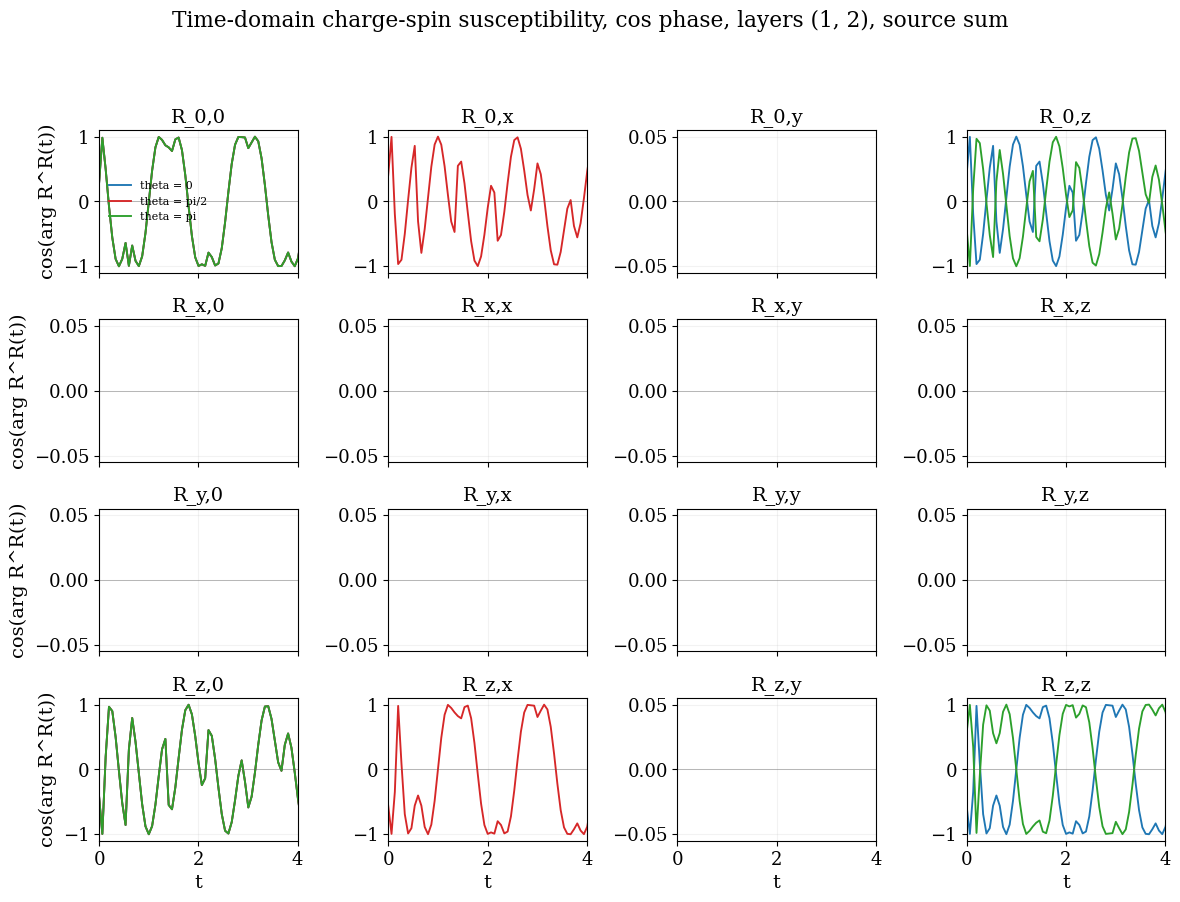

In [16]:
# -----------------------------
# Time-domain full charge-spin tensor plot
# -----------------------------
cosangle(z) = cos(angle(z))
sinangle(z) = sin(angle(z))

time_tensor_partχ = cosangle                # real, imag, abs, angle, cosangle, or sinangle
time_unwrap_phaseχ = false                  # false keeps arg in [-pi, pi]; true shows accumulated phase
time_phase_amp_tolχ = 1e-8                  # hide phase where |R(t)| is too small
time_phase_guidesχ = true                   # draw +/- pi guides for wrapped phase
time_tensor_zero_tolχ = @isdefined(tensor_zero_tolχ) ? tensor_zero_tolχ : 1e-10
time_xlimχ = (0.0, min(15.0, last(tsχ)))


function label_time_tensor_partχ(part)
    part === real && return "Re"
    part === imag && return "Im"
    part === abs && return "Abs"
    part === angle && return time_unwrap_phaseχ ? "Unwrapped phase" : "Phase"
    part === cosangle && return "cos phase"
    part === sinangle && return "sin phase"
    return string(part)
end

time_tensor_part_labelχ = label_time_tensor_partχ(time_tensor_partχ)
time_tensor_ylabelχ = time_tensor_partχ === angle ? "arg R^R(t) [rad]" :
                       time_tensor_partχ === cosangle ? "cos(arg R^R(t))" :
                       time_tensor_partχ === sinangle ? "sin(arg R^R(t))" :
                       time_tensor_part_labelχ * " R^R(t)"

function unwrap_phase_lineχ(phi)
    out = collect(phi)
    for i in 2:length(out)
        Δ = out[i] - out[i - 1]
        while Δ > π
            out[i] -= 2π
            Δ -= 2π
        end
        while Δ < -π
            out[i] += 2π
            Δ += 2π
        end
    end
    return out
end

function project_time_componentχ(z, part)
    part === abs && return abs(z)
    part === angle && return angle(z)
    part === cosangle && return cos(angle(z))
    part === sinangle && return sin(angle(z))
    return part(z)
end

function clean_time_component_lineχ(y; tol=time_tensor_zero_tolχ)
    out = collect(y)
    finite_idx = findall(isfinite, out)
    isempty(finite_idx) && return out

    if maximum(abs.(out[finite_idx])) < tol
        out[finite_idx] .= 0.0
    else
        for i in finite_idx
            if abs(out[i]) < tol
                out[i] = 0.0
            end
        end
    end
    return out
end

function build_time_component_lineχ(Rt, A, B, part)
    zline = [Rt[A, B, it] for it in axes(Rt, 3)]

    if part in (angle, cosangle, sinangle)
        phi = angle.(zline)
        if part === angle
            y = time_unwrap_phaseχ ? unwrap_phase_lineχ(phi) : phi
        elseif part === cosangle
            y = cos.(phi)
        else
            y = sin.(phi)
        end
        amp = abs.(zline)
        return [amp[i] < time_phase_amp_tolχ ? NaN : y[i] for i in eachindex(y)]
    end

    return clean_time_component_lineχ([project_time_componentχ(z, part) for z in zline])
end

if !(@isdefined(Rtime_by_angleχ))
    error("Run the time-domain compute cell before plotting the time response.")
end

fig, axs = subplots(4, 4, figsize=(12.0, 9.2), sharex=true)
colors_timeχ = ["#1f77b4", "#d62728", "#2ca02c"]
for A in 1:4, B in 1:4
    ax = axs[A, B]
    for ia in eachindex(time_anglesχ)
        y = build_time_component_lineχ(Rtime_by_angleχ[ia], A, B, time_tensor_partχ)
        ax.plot(tsχ, y, lw=1.35, color=colors_timeχ[ia], label="theta = " * time_angle_labelsχ[ia])
    end
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    if time_tensor_partχ === angle && !time_unwrap_phaseχ && time_phase_guidesχ
        ax.axhline(π, color="0.55", lw=0.5, ls=":", alpha=0.45)
        ax.axhline(-π, color="0.55", lw=0.5, ls=":", alpha=0.45)
    end
    ax.set_title("R_" * charge_spin_labels[A] * "," * charge_spin_labels[B])
    ax.grid(alpha=0.16)
    ax.set_xlim(0.0,25)#time_xlimχ...)
    if A == 4
        ax.set_xlabel("t")
    end
    if B == 1
        ax.set_ylabel(time_tensor_ylabelχ)
    end
    ax.set_xlim(0,4)
end

axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("Time-domain charge-spin susceptibility, " * time_tensor_part_labelχ *
             ", layers " * string(time_tensor_layer_pairχ) *
             ", source " * string(time_tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 1, 0.94))


### Cumulative memory moments

The next cell turns the time-domain susceptibility into the cumulative kernels used in a slow-spin or LL-type expansion,

$$J(t)=\int_0^t d\tau\,R^R(\tau),\qquad \alpha(t)=s_\alpha\int_0^t d\tau\,\tau R^R(\tau).$$

It computes both `Jcum_by_angleχ` and `alphacum_by_angleχ`; the first figure below plots $J(t)$. For comparison with the Potthoff/Sayad memory-kernel expressions, use `moment_partχ = real` unless you are intentionally diagnosing complex residuals or mixed components. A plateau as $t$ increases means the local-in-time approximation is controlled; persistent oscillations mean the response has long memory.


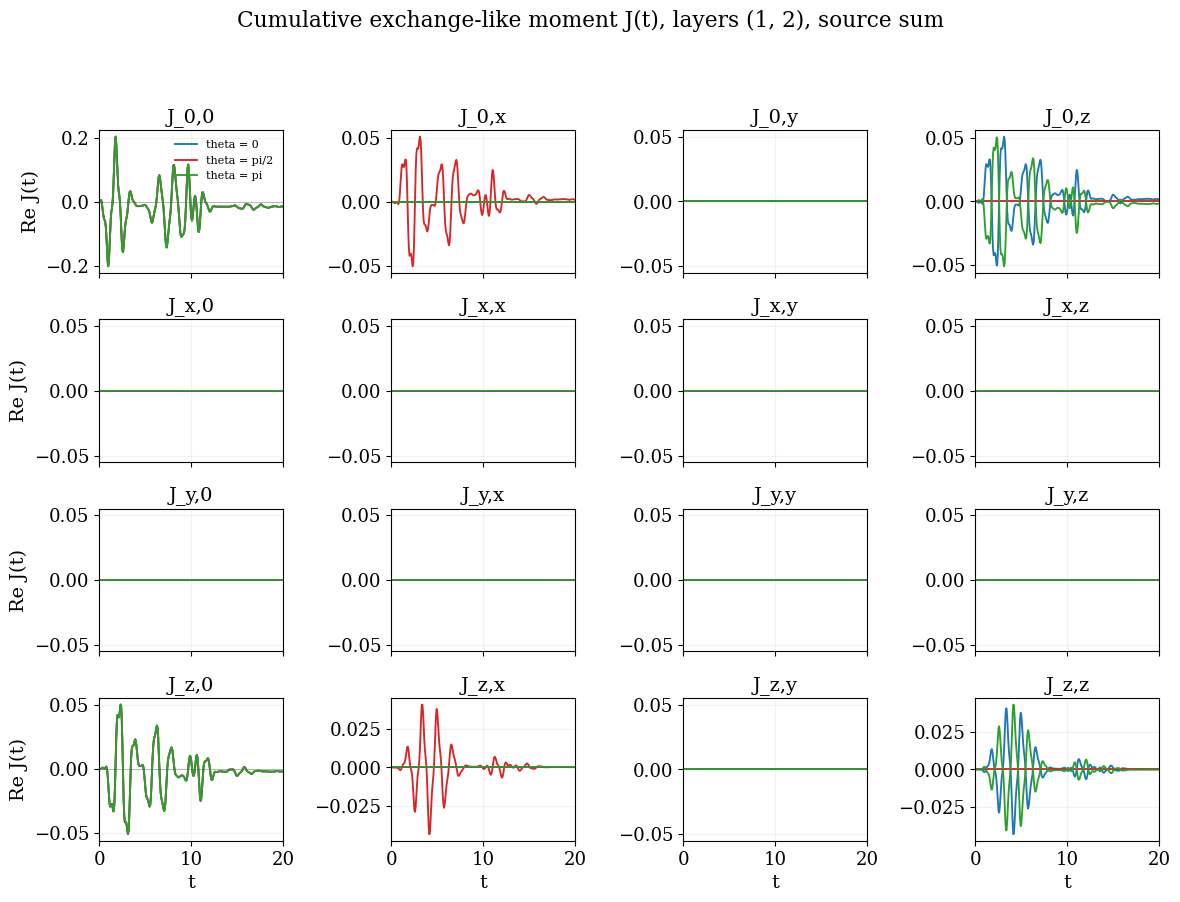

In [18]:
# -----------------------------
# Cumulative exchange-like moment J(t) = integral_0^t dτ chi(τ)
# -----------------------------
if !(@isdefined(Rtime_by_angleχ))
    error("Run the time-domain compute cell before computing J(t) and alpha(t).")
end

moment_partχ = real#abs#real                    # real, imag, or abs
moment_part_labelχ = moment_partχ === real ? "Re" : moment_partχ === imag ? "Im" : "Abs"
moment_zero_tolχ = @isdefined(tensor_zero_tolχ) ? tensor_zero_tolχ : 1e-10
moment_xlimχ = (0.0, min(25.0, last(tsχ)))
alpha_moment_signχ = -1.0              # from M(t-τ)=M(t)-τ*dM/dt; change if your torque convention differs

function cumulative_trapezoid_complexχ(y, ts)
    out = zeros(ComplexF64, length(ts))
    for i in 2:length(ts)
        dt = ts[i] - ts[i - 1]
        out[i] = out[i - 1] + 0.5 * dt * (y[i] + y[i - 1])
    end
    return out
end

function project_moment_componentχ(z, part)
    part === abs && return abs(z)
    return part(z)
end

function clean_moment_lineχ(y; tol=moment_zero_tolχ)
    out = collect(y)
    if maximum(abs.(out)) < tol
        out .= 0.0
    else
        out = [abs(v) < tol ? 0.0 : v for v in out]
    end
    return out
end

function compute_cumulative_J_alphaχ(Rtime_by_angle, ts)
    J_by_angle = Vector{Array{ComplexF64, 3}}(undef, length(Rtime_by_angle))
    alpha_by_angle = Vector{Array{ComplexF64, 3}}(undef, length(Rtime_by_angle))

    for ia in eachindex(Rtime_by_angle)
        Rt = Rtime_by_angle[ia]
        Jt = zeros(ComplexF64, 4, 4, length(ts))
        alphat = zeros(ComplexF64, 4, 4, length(ts))

        for A in 1:4, B in 1:4
            chi_line = [Rt[A, B, it] for it in axes(Rt, 3)]
            Jt[A, B, :] .= cumulative_trapezoid_complexχ(chi_line, ts)
            alphat[A, B, :] .= alpha_moment_signχ .* cumulative_trapezoid_complexχ(ts .* chi_line, ts)
        end

        J_by_angle[ia] = Jt
        alpha_by_angle[ia] = alphat
    end

    return J_by_angle, alpha_by_angle
end

Jcum_by_angleχ, alphacum_by_angleχ = compute_cumulative_J_alphaχ(Rtime_by_angleχ, tsχ)

fig, axs = subplots(4, 4, figsize=(12.0, 9.2), sharex=true)
colors_momentχ = ["#1f77b4", "#d62728", "#2ca02c"]
for A in 1:4, B in 1:4
    ax = axs[A, B]
    for ia in eachindex(time_anglesχ)
        y = clean_moment_lineχ([project_moment_componentχ(Jcum_by_angleχ[ia][A, B, it], moment_partχ)
                                for it in axes(Jcum_by_angleχ[ia], 3)])
        ax.plot(tsχ, y, lw=1.35, color=colors_momentχ[ia], label="theta = " * time_angle_labelsχ[ia])
    end
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax.set_title("J_" * charge_spin_labels[A] * "," * charge_spin_labels[B])
    ax.grid(alpha=0.16)
    ax.set_xlim(0,20)#moment_xlimχ...)
    if A == 4
        ax.set_xlabel("t")
    end
    if B == 1
        ax.set_ylabel(moment_part_labelχ * " J(t)")
    end
end
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("Cumulative exchange-like moment J(t), layers " * string(time_tensor_layer_pairχ) *
             ", source " * string(time_tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 1, 0.94))


### Damping-like moment plot

This cell reuses `alphacum_by_angleχ` from the previous cell and only plots the damping-like moment. The sign includes `alpha_moment_signχ`, which encodes the convention from the expansion $M(t-\tau)=M(t)-\tau\dot M(t)$.

The sign of a single tensor component is not by itself a complete damping or antidamping criterion. The physical damping is determined after projecting the full kernel onto the actual magnetic mode and applying the torque convention.


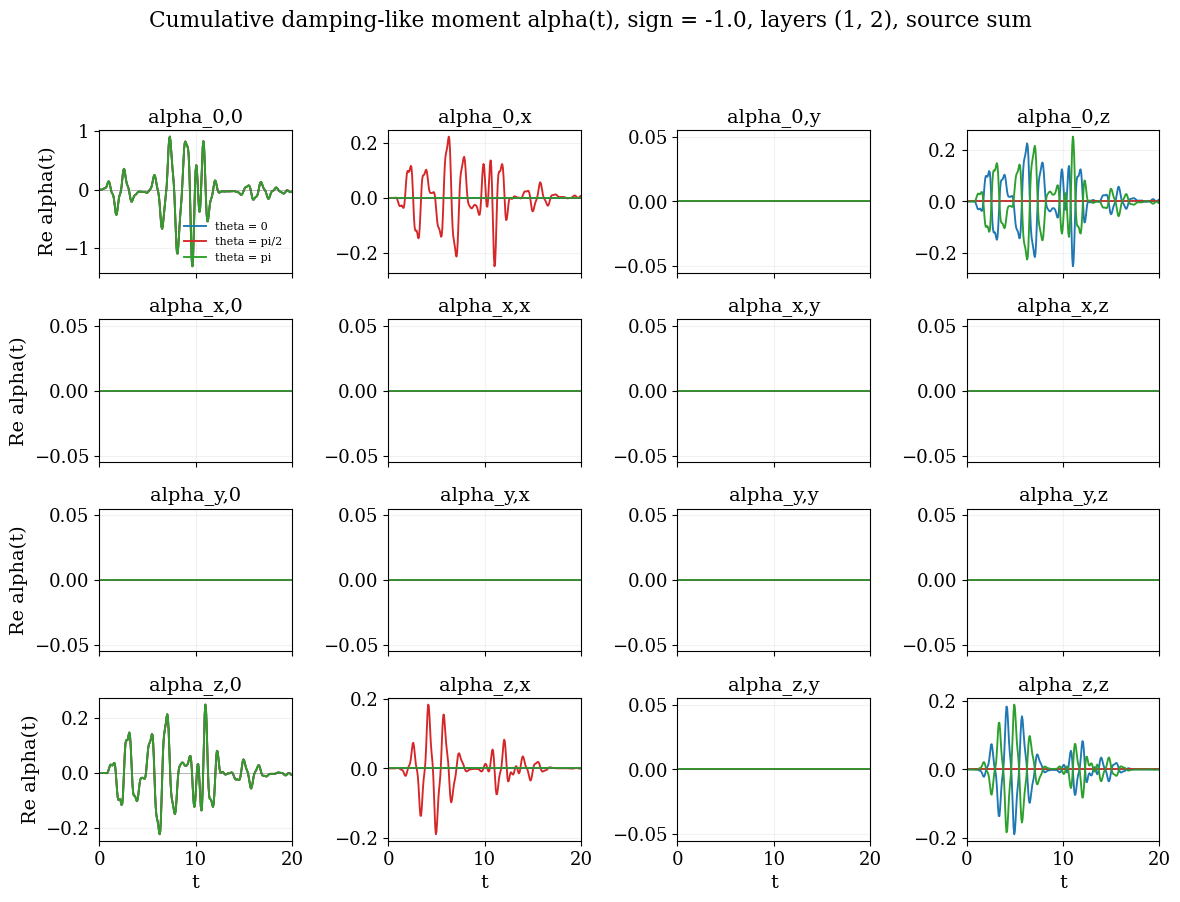

In [22]:
# -----------------------------
# Cumulative damping-like moment alpha(t) = sign * integral_0^t dτ τ chi(τ)
# -----------------------------
if !(@isdefined(alphacum_by_angleχ))
    error("Run the J(t) cumulative-moment cell first; it computes both Jcum_by_angleχ and alphacum_by_angleχ.")
end

alpha_partχ = real#abs#moment_partχ             # real, imag, or abs
alpha_part_labelχ = alpha_partχ === real ? "Re" : alpha_partχ === imag ? "Im" : "Abs"
alpha_xlimχ = moment_xlimχ

fig, axs = subplots(4, 4, figsize=(12.0, 9.2), sharex=true)
colors_alphaχ = ["#1f77b4", "#d62728", "#2ca02c"]
for A in 1:4, B in 1:4
    ax = axs[A, B]
    for ia in eachindex(time_anglesχ)
        y = clean_moment_lineχ([project_moment_componentχ(alphacum_by_angleχ[ia][A, B, it], alpha_partχ)
                                for it in axes(alphacum_by_angleχ[ia], 3)])
        ax.plot(tsχ, y, lw=1.35, color=colors_alphaχ[ia], label="theta = " * time_angle_labelsχ[ia])
    end
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax.set_title("alpha_" * charge_spin_labels[A] * "," * charge_spin_labels[B])
    ax.grid(alpha=0.16)
    ax.set_xlim(0,20)#alpha_xlimχ...)
    if A == 4
        ax.set_xlabel("t")
    end
    if B == 1
        ax.set_ylabel(alpha_part_labelχ * " alpha(t)")
    end
end
axs[1, 1].legend(frameon=false, fontsize=8)
fig.suptitle("Cumulative damping-like moment alpha(t), sign = " * string(alpha_moment_signχ) *
             ", layers " * string(time_tensor_layer_pairχ) *
             ", source " * string(time_tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 1, 0.94))


### Sanity check: why $J(t)$ and $\alpha(t)$ can look similar

The previous two figures plot the correct accumulated quantities, but every panel auto-scales its own vertical axis. Since both moments come from the same retarded kernel, their shapes can look similar even when their magnitudes and limits are different.

This diagnostic keeps the two definitions explicit. The upper row compares the normalized cumulative moments,

$$J(t)=\int_0^t d\tau\,\chi(\tau),\qquad \alpha(t)=s_\alpha\int_0^t d\tau\,\tau\chi(\tau),$$

while the lower row compares the effective integrands $\chi(t)$ and $s_\alpha t\chi(t)$. If the lower row differs, then the calculation is not accidentally plotting the same object twice; the similarity is coming from the structure of the same underlying kernel.


Moment sanity check for theta = pi/2
component    max|J|        max|alpha|    final J       final alpha
00          2.0442e-01    1.3132e+00    -1.5492e-02    -2.7655e-02
0x          5.0724e-02    2.4983e-01    +1.8319e-03    +2.9519e-03
z0          5.0724e-02    2.4983e-01    -1.8319e-03    -2.9519e-03
zx          4.3463e-02    1.8932e-01    +2.2338e-04    +3.3283e-04


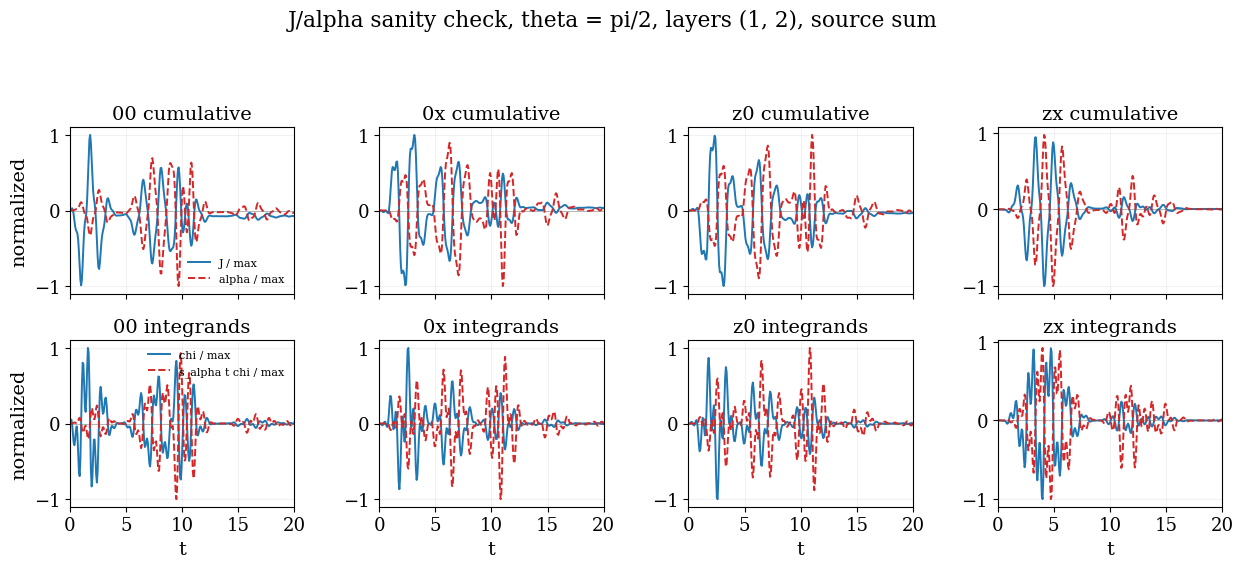

In [23]:

# -----------------------------
# Sanity check for J(t) versus alpha(t)
# -----------------------------
if !(@isdefined(Jcum_by_angleχ)) || !(@isdefined(alphacum_by_angleχ)) || !(@isdefined(Rtime_by_angleχ))
    error("Run the time-domain and cumulative-moment cells before this sanity check.")
end

moment_sanity_angle_indexχ = min(2, length(time_anglesχ))
moment_sanity_componentsχ = [(1, 1), (1, 2), (4, 1), (4, 2)]  # 00, 0x, z0, zx by default
moment_sanity_xlimχ = (0.0, min(20.0, last(tsχ)))
moment_sanity_partχ = real

function normalize_for_shapeχ(y; tol=1e-14)
    scale = maximum(abs.(y))
    scale < tol && return zeros(Float64, length(y)), scale
    return y ./ scale, scale
end

function finite_difference_lineχ(y, ts)
    out = zeros(Float64, length(y))
    length(y) < 2 && return out
    out[1] = (y[2] - y[1]) / (ts[2] - ts[1])
    out[end] = (y[end] - y[end - 1]) / (ts[end] - ts[end - 1])
    for it in 2:(length(y) - 1)
        out[it] = (y[it + 1] - y[it - 1]) / (ts[it + 1] - ts[it - 1])
    end
    return out
end

function projected_lineχ(A, B, arr, part)
    return [project_moment_componentχ(arr[A, B, it], part) for it in axes(arr, 3)]
end

iaχ = moment_sanity_angle_indexχ
fig, axs = subplots(2, length(moment_sanity_componentsχ), figsize=(3.2 * length(moment_sanity_componentsχ), 5.8), sharex=true)

println("Moment sanity check for theta = " * time_angle_labelsχ[iaχ])
println("component    max|J|        max|alpha|    final J       final alpha")

for (icol, (A, B)) in enumerate(moment_sanity_componentsχ)
    Jline = projected_lineχ(A, B, Jcum_by_angleχ[iaχ], moment_sanity_partχ)
    alphline = projected_lineχ(A, B, alphacum_by_angleχ[iaχ], moment_sanity_partχ)
    chiline = projected_lineχ(A, B, Rtime_by_angleχ[iaχ], moment_sanity_partχ)
    alpha_integrand = alpha_moment_signχ .* tsχ .* chiline

    Jnorm, Jscale = normalize_for_shapeχ(Jline)
    alphanorm, alphascale = normalize_for_shapeχ(alphline)
    chinorm, chiscale = normalize_for_shapeχ(chiline)
    alphainorm, alphaiscale = normalize_for_shapeχ(alpha_integrand)

    labelχ = charge_spin_labels[A] * charge_spin_labels[B]
    @printf("%-8s    %.4e    %.4e    %+ .4e    %+ .4e\n", labelχ, Jscale, alphascale, Jline[end], alphline[end])

    ax1 = axs[1, icol]
    ax1.plot(tsχ, Jnorm, lw=1.4, color="#1f77b4", label="J / max")
    ax1.plot(tsχ, alphanorm, lw=1.4, color="#d62728", ls="--", label="alpha / max")
    ax1.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax1.set_title(labelχ * " cumulative")
    ax1.grid(alpha=0.16)
    ax1.set_xlim(moment_sanity_xlimχ...)
    if icol == 1
        ax1.set_ylabel("normalized")
    end

    ax2 = axs[2, icol]
    ax2.plot(tsχ, chinorm, lw=1.4, color="#1f77b4", label="chi / max")
    ax2.plot(tsχ, alphainorm, lw=1.4, color="#d62728", ls="--", label="s_alpha t chi / max")
    ax2.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax2.set_title(labelχ * " integrands")
    ax2.grid(alpha=0.16)
    ax2.set_xlim(moment_sanity_xlimχ...)
    ax2.set_xlabel("t")
    if icol == 1
        ax2.set_ylabel("normalized")
    end
end

axs[1, 1].legend(frameon=false, fontsize=8)
axs[2, 1].legend(frameon=false, fontsize=8)
fig.suptitle("J/alpha sanity check, theta = " * time_angle_labelsχ[iaχ] *
             ", layers " * string(time_tensor_layer_pairχ) *
             ", source " * string(time_tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 1, 0.92))


In [32]:
#Opodvmin_angle_tensorχ

-6.219383203009725